# Python Final Task: Using Monte Carlo simulations to fit astrophysical lines of Alcyone

PHAS0020: Practical Astrophysics and Computing | Feb 2026

## Table of contents
- [TASK A: Abstract and preparation](#TASK-A:-Abstract-and-Preparation)
    - [A.1: Abstract](#A.1:-Abstract)
    - [A.2: Image Loading](#A.2:-Image-Loading)
- [TASK B: Image prep for spectra extraction](#TASK-B:-Image-prep-for-spectra-extraction)
    - [B.1: Order and row identification](#B.1:-Order-and-row-identification)
    - [B.2: Binning as aperture photometry](#B.2:-Binning-as-aperture-photometry)
    - [B.3: Pre-emptive background subtraction](#B.3:-Pre-emptive-background-subtraction)
    - [B.4: Repeat the steps for $H_\beta$ line](#B.4:-Repeat-the-steps-for-$H_\beta$-line)
- [TASK C: Standard spectral analysis and identification of main line positions](#TASK-C:-Standard-spectral-analysis-and-identification-of-main-line-positions)
    - [C.1: Normalisation of continuum](#C.1:-Normalisation-of-continuum)
    - [C.2: Line peak fits](#C.2:-Line-peak-fits)
    - [C.3: Repeat spectral analysis for $H_\beta$](#C.3:-Repeat-spectral-analysis-for-$H_\beta$)
    - [C.4: Summary of obtained wavelengths and doppler velocities](#C.4:-Summary-of-obtained-wavelengths-and-doppler-velocities) 
- [TASK D: Using a Monte Carlo approach to perform complex fitting](#TASK-D:-Using-a-Monte-Carlo-approach-to-perform-complex-fitting)
    - [D.1: Fit of $H_\alpha$](#D.1:-Fit-of-$H_\alpha$)
    - [D.2: Monte Carlo set up](#D.2:-Monte-Carlo-set-up)
    - [D.3: Fine tuning](#D.3:-Fine-tuning)
    - [D.4: Fitting the $H_\beta$ line](#D.4:-Fitting-the-$H_\beta$-line)
- [TASK E: Conclusions](#TASK-E:-Conclusions)
- [References](#References)
  
  

## TASK A: Abstract and Preparation

### A.1: Abstract

<div class="alert alert-success">
This Python Final Task investigates the spectrum of Alcyone, a B7 star in The Pleides open star cluster. In this task we will look at two spectral lines of Alcyone and attempt to extract their wavelength and ultimately the radial velocity of Alcyone through a series of complex fitting methods.

We use FITS images taken by the echelle spectrometer on the Perren Telescope at the UCL Observatory (UCLO). Upon identifying the $H_\alpha$ and $H_\beta$ spectral lines in the FITS images, we sample each of the lines and two corresponding lines of background which are used to subtract the median background on our spectral line and hence perform aperture photometry.

Subsequently, we fit the continuum of each of the lines with a second-degree polynomial fit and perform normalisation of the spectral lines. We then fit the spectral line itself with a second-degree polynomial fit and and use our obtained fit to calculate the vertex of the parabola which we estimate to be out $\lambda_\alpha$ and $\lambda_\beta$. We obtain the values $\lambda_\alpha$ = 656.21110 ± 0.00172 nm and $\lambda_\beta$ = 485.87352 ± 0.00551 nm. We calculate the doppler shift velocity accounting for heliospheric correction and find $v_\alpha$ = 4.262 ± 0.788 km/s and $v_\beta$ = 112.536 ± 3.402 km/s. 

In order to take our spectral analysis a step further, we fit the spectral lines using a series of Gaussian functions and simulating their paramters by Monte Carlo simulations. Instead of using the least squares residuals as an indicator we use a $\chi ^2$ as our MC simulation is ultimately a fit of a single curve consiting of multiple Gaussians. We obtain a series of fit parameters for each Gaussian we use to fit each spectral line and use the mean obtained by the MC to calculte the wavelength of each Gaussian and the doppler velocity it yields. For the $H_{\alpha}$ $v_{emission}$ = 3.505 ± 5.296 km/s and the $v_{absorption}$ = -1.822 ± 13.232 km/s and for the $H_{\beta}$ we get $v_{absorption}$ = 65.229 ± 1.779 km/s, $v_{peak1}$ = 107.824 ± 1.778 km/s and $v_{peak2}$ = 17.273 ± 1.779 km/s. Comparing it to the literature values of radial velocity v = 5.4 km/s  $^{[1]}$, we conclude the $H_{\alpha}$ line to be a better indicator of radial velocity due to its less complex shape than the $H_{\beta}$ line.
</div>

**A short introduction:**

The subject of our spectral analysis is the B7IIIe blue giant star Alcyone $^{[2]}$. Alcyone's effective temperature is $T_{eff}$ =12258 ± 505 K $^{[2]}$.  In most B-type stars we expect to encounter strong absorption spectra of HI and He II, nevertheless their fast rotations can result in emission of the rotating disk overpowering the absorption line from the star $^{[3]}$. This usually presents a rather complex picture when it comes to analysis of spectral line of stars like Alcyone. For many stars, the $H_\alpha$ Balmer line profile can be used to derive effective temperature $T_{eff}$, due to its indepenednace of interstellar reddening$^{[4]}$.

Most of the edges of B-type stars are doppler shifted hence it might affect the shape of spectral lines. Additionally, B-type stars might exhibit pressure variations based on the size of the star, which impacts the line profile, especially when it comes to hydrogen line of the Balmer series in early type stars. For this reason, equivalent width is considered instead of line depth when creating ratios between spectral lines to infer  $T_{eff}$ using a Curve of Growth$^{[5]}$. 

### A.2: Image Loading

Before we start working with our data, let us import some relevant libraries:

In [5]:
#import libraries 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import statistics as stats
from scipy import optimize
import os
import random
import pandas as pd

#as we will be working with FITS images
from astropy.io import fits
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astropy import units as u

For this investigation we will use four images taken by Alcyone on the 24th of January. These images were taken by the UCL Observatory and are in the FITS image format. Let us load and open each now.

In [6]:
#find directory 
home_dir = os.getcwd()+'/'
print ("The Home Directory is set to:", home_dir) 

#load images
image0= fits.open(f"{home_dir}25_Tau_2023-01-24_Light_000.fits")
fits_image0 = image0[0].data

image1= fits.open(f"{home_dir}25_Tau_2023-01-24_Light_001.fits")
fits_image1 = image1[0].data

image2= fits.open(f"{home_dir}25_Tau_2023-01-24_Light_002.fits")
fits_image2 = image2[0].data

image3= fits.open(f"{home_dir}25_Tau_2023-01-24_Light_003.fits")
fits_image3 = image3[0].data

The Home Directory is set to: /Users/klarakurucova/Desktop/UCL /Practical astrophysics and computing /python final task/


FileNotFoundError: [Errno 2] No such file or directory: '/Users/klarakurucova/Desktop/UCL /Practical astrophysics and computing /python final task/25_Tau_2023-01-24_Light_000.fits'

We will now print the header of each FITS image to examine the exposure times used, as we only aim to use three images with the same integration time.

In [3]:
#fits_inf = fits.open("stacked_M13_blue.fits")

#image0
header0 = image0[0].header
print(f"The exposure time for image_0 is :{header0['EXPTIME']}")

#image1
header1 = image1[0].header
print(f"The exposure time for image_1 is :{header1['EXPTIME']}")

#image2
header2 = image2[0].header
print(f"The exposure time for image_2 is :{header2['EXPTIME']}")

#image3
header3 = image3[0].header
print(f"The exposure time for image_3 is :{header3['EXPTIME']}")



NameError: name 'image0' is not defined

By accessing the header, we see that image 0 has a different exposure time to the remaining three images. Hence we will proceed our investiagtion only using images 1-3. Let us now visualise one of these images. To do this appropriately we will run a short function that finds some basic stats of FITS images.  

In [22]:
#run some stats
def quick_look (image):
    """
    This function runs some basic stats one our FITS image and returns appropriate vmin & vmax
    Input:
    fits image
    
    Output:
    mean, standard deviation, vmin, vmax
    """
    mean_image = np.mean(image)
    std_image = np.std(image)
    vmin_image = mean_image - 3 * std_image
    vmax_image = mean_image + 20 * std_image
    print (f"The mean of the FITS image is {mean_image}")
    print (f"The standard deviation of the FITS image is {std_image}")
    print (f"The vmin of the FITS image is {vmin_image}")
    print (f"The vmax of the FITS image is {vmax_image}")
    

    return mean_image, std_image, vmin_image, vmax_image

#run quick look
mean1, std1, vmin1, vmax1 = quick_look(fits_image1)

The mean of the FITS image is 2441.4862728118896
The standard deviation of the FITS image is 735.2412052954229
The vmin of the FITS image is 235.76265692562083
The vmax of the FITS image is 17146.310378720347


Having computed the stats, we can now plot our FITS image with and appropriate vmin and vmax boundary. We aim to look for two eschelle lines in this FITS image and correctly identify them. 

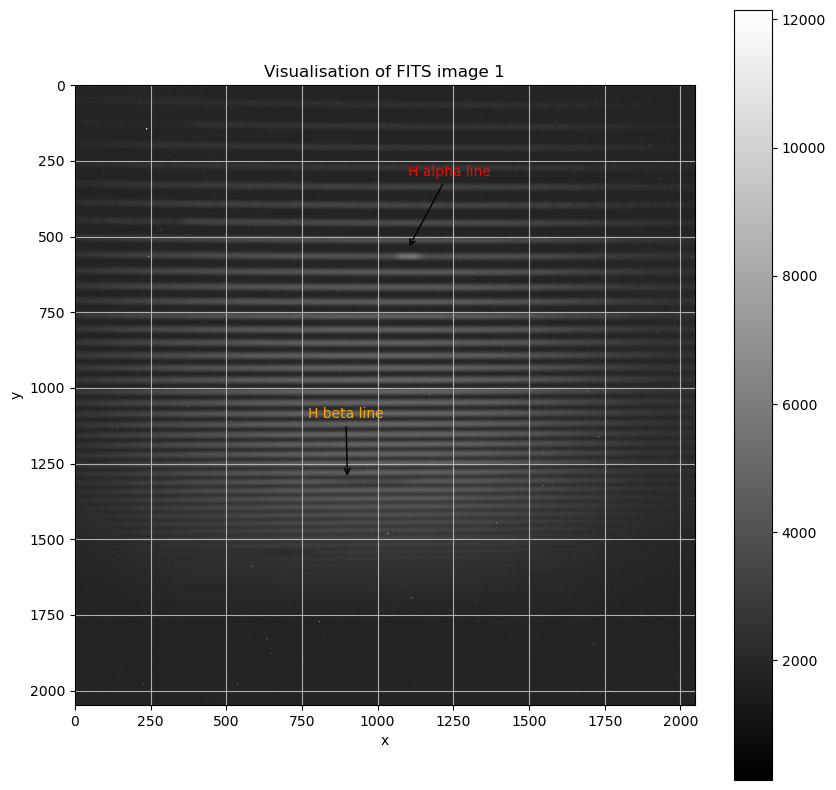

In [25]:
#plot image1
plt.figure (figsize= (10,10))
plt.imshow(fits_image1, cmap='gray', vmin=vmin1 - 100, vmax=vmax1 - 5000)
plt.title ('Visualisation of FITS image 1')
plt.annotate("H alpha line", xy=(1100, 540), xytext=(1100, 300), color = 'red', arrowprops=dict(arrowstyle="->"))
plt.annotate("H beta line", xy=(900, 1300), xytext=(770, 1100), color = 'orange', arrowprops=dict(arrowstyle="->"))
#plt.plot((950,950), (0,2048), "--" , label = 'H alpha line')
plt.xlabel('x')
plt.ylabel ('y')
plt.colorbar()
plt.grid()
plt.show()

We identified the $H_\alpha$ emission echelle line by an increase in intensity compared to the surroundings, whereas the $H_\beta$ line is characterized by a dip in brigthness as it is an absorption line. As stated in our introduction, we exepcted both of the lines to be absorption lines, nevertheless we see $H_\alpha$ as an emission line, indicating that Alcyone's fast rotation does indeed overpower the absoprtion line creating and showing an emission line instead. 

As we have three FITS images with the same exposure time, we can average them to reduce the noise of our data. 

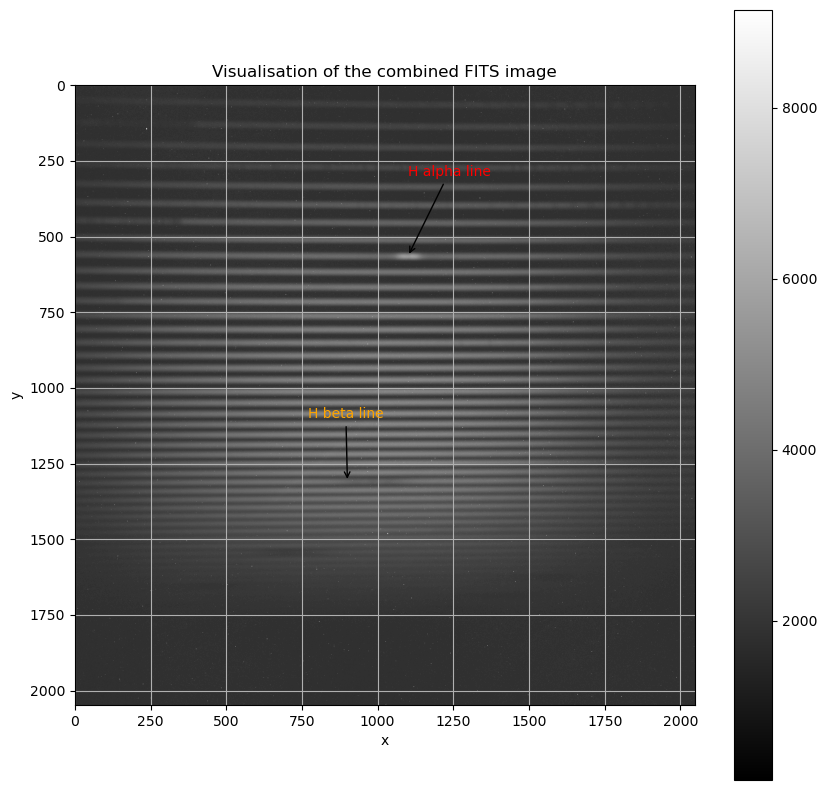

In [29]:
#taking av of the three images
av_image = (fits_image1 + fits_image2 + fits_image3) / 3

#plot av image
plt.figure (figsize= (10,10))
plt.imshow(av_image, cmap='gray', vmin=vmin1 - 100, vmax=vmax1 - 8000)
plt.title ('Visualisation of the combined FITS image')
plt.annotate("H alpha line", xy=(1100, 565), xytext=(1100, 300), color = 'red', arrowprops=dict(arrowstyle="->"))
plt.annotate("H beta line", xy=(900, 1310), xytext=(770, 1100), color = 'orange', arrowprops=dict(arrowstyle="->"))
plt.xlabel('x')
plt.ylabel ('y')
plt.colorbar()
plt.grid()
plt.show()

Nevertheless, there may be some limitations to this method. Firstly, if our data posseses large outliers (ex: cosmic rays) it can reflect badly on our combined image. Additionally, if our image frames are not perfectly aligned the range of our identified eschelle lines might get slightly convoluted. Futhermore, with only three images the improvment in the signal to noise ratio might not be substantially visible nevertheless it will bring some enhancements to the data set. 

## TASK B: Image prep for spectra extraction

### B.1: Order and row identification 

We will now take a column slice of our FITS image and create a plot that will show us the variations between the signals and the background. We then identify a threshold at which we consider the "peaks" the signals and the "dips" as the background. This will allow us to read off how many rows are in each spectral line so we use an appropriate slice for binning. 

Text(0, 0.5, 'y')

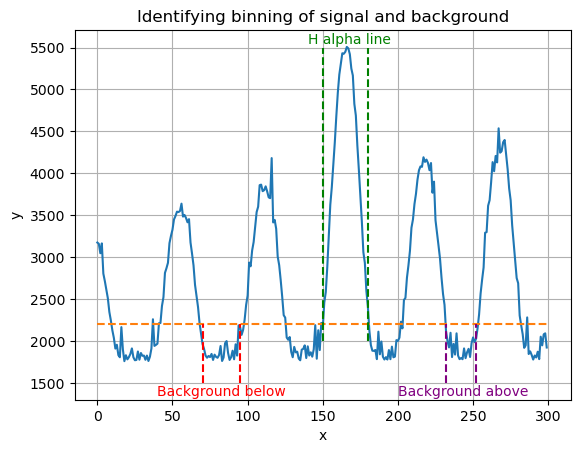

In [35]:
#determine size of binning for alpha line

#plot the slice
plt.plot(av_image[400:700, 1100])

#determine the threshold
plt.plot((0,300), (2200,2200), "--" , label = 'Threshold')

#find the width of h alpha
plt.plot((150,150), (2000,5500), "--" , label = 'H alpha signal', color = 'green')
plt.plot((180,180), (2000,5500), "--" , label = 'H alpha signal', color = 'green')
plt.text(140, 5550, 'H alpha line', color = 'green')

#find the width of background below 
plt.plot((70,70), (1500,2200), "--" , label = 'below signal', color = 'red')
plt.plot((95,95), (1500,2200), "--" , label = 'below signal', color = 'red')
plt.text(40, 1350, 'Background below', color = 'red')

#find the width of background above
plt.plot((232,232), (1500,2200), "--" , label = 'above signal', color = 'purple')
plt.plot((252,252), (1500,2200), "--" , label = 'above signal', color = 'purple')
plt.text(200, 1350, 'Background above', color = 'purple')

plt.grid()
plt.title ('Identifying binning of signal and background')
plt.xlabel('x')
plt.ylabel ('y')

This approach has showed that the $H_\alpha$ line consists of 30 rows where as our backgrounds above and below are 20. Hence through this rather quantitiave method we determined the width of each line. Let us apply the appropriate slices below.

In [38]:
#selecting the eschelle line 
alpha_eschelle = av_image [550:580, 0:2048] #y-axis first

#selecting the above background line 
alpha_above = av_image [632:652, 0:2048]

#selecting the below background line 
alpha_below = av_image [470:490, 0:2048]


Let us now plot our sliced areas on our FITS image just for visual clarification of the rows we have chosen.

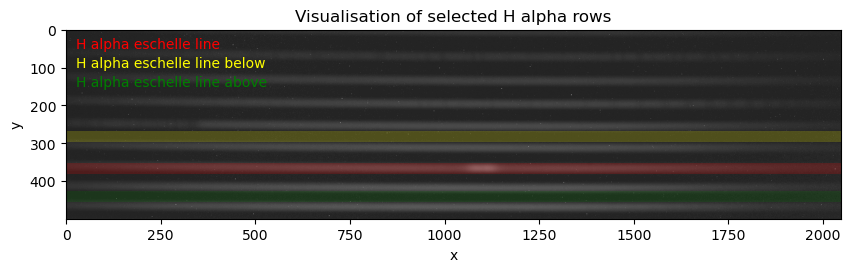

In [41]:
#define areas that we will plot
rect_alp = patches.Rectangle((0, 360), 2048, 10, linewidth=5, edgecolor='red', alpha = 0.2, facecolor='none')
rect_alp_below = patches.Rectangle((0, 275), 2048, 10, linewidth=5, edgecolor='yellow', alpha = 0.2, facecolor='none')
rect_alp_above = patches.Rectangle((0, 435), 2048, 10, linewidth=5, edgecolor='green', alpha = 0.2, facecolor='none')

#select slice of FITS image 
section_alpha_line = av_image [200:700,] #y-coord first

#plotting our selected 
plt.figure (figsize= (10,10))
plt.imshow(section_alpha_line, cmap='gray', vmin=vmin1 - 100, vmax=vmax1 - 5000)

#plot sections
plt.gca().add_patch(rect_alp)
plt.gca().add_patch(rect_alp_above)
plt.gca().add_patch(rect_alp_below)

#plt text
plt.text(25, 50, 'H alpha eschelle line', color = 'red')
plt.text(25, 100, 'H alpha eschelle line below', color = 'yellow')
plt.text(25, 150, 'H alpha eschelle line above', color = 'green')

plt.title ('Visualisation of selected H alpha rows')
plt.xlabel('x')
plt.ylabel ('y')
plt.show()

### B.2: Binning as aperture photometry

To apply binning to our arrays, we will sum the pixels in each of our 2048 columns of each array to create a 1D array for the eschelle $H_\alpha$ line, the above line and the below line. By summing vertically we will remove the background from our echelle orders.

In [45]:
#summing vertically 
alpha_eschelle_sum = alpha_eschelle.sum(axis = 0) #axis = 0 sums over y-axis 
alpha_above_sum = alpha_above.sum(axis = 0)
alpha_below_sum = alpha_below.sum(axis = 0)

#check the shape
print (alpha_eschelle_sum.shape)

(2048,)


### B.3: Pre-emptive background subtraction

To conduct aperture photometry on our source, we will consider our binned eschelle $H_\alpha$ line as our signal and the above and below lines as background that will be subtracted from the signal. Nevertheless, we cannot subtract these directly from our signal, but will have to find the average background per row which will be done by dividing our computed sum in B.2 by the number of rows. Then we will scale it to the source and ultimately subtract it.

Although we could easily deduce the number of rows sliced by just scrolling back up to the relevant section, let us simply compute it below:

In [49]:
#number of rows in our selected lines 
rows_alpha = alpha_eschelle.shape[0]
rows_alpha_above = alpha_above.shape[0]
rows_alpha_below = alpha_below.shape[0]

print (f"The number of rows in  the H alpha line is {rows_alpha}")
print (f"The number of rows in  the above background of the H alpha line is {rows_alpha_above}")
print (f"The number of rows in  the below background of the H alpha line is {rows_alpha_below}")


The number of rows in  the H alpha line is 30
The number of rows in  the above background of the H alpha line is 20
The number of rows in  the below background of the H alpha line is 20


Having the identified the number of rows in each line, we can now find the background per row in the above and below row. We will then find their median which will be scaled by the number of rows in our signal line and ultimately subtracted from the signal of the eschelle line, performing simple aperture photomtery according to: 
$$
S \;=\; \sum_{i=1} P_i - (n_{rows} *B)
$$

Where:
- $S$ = Overall signal
- $P_i$ = signal of eschelle line
- $n_{rows}$ = number of rows in eschelle line
- $B$ = median background

In [52]:
#computing the background

#find bg per row
bg_alpha_above_per_row = alpha_above_sum / rows_alpha_above
bg_alpha_below_per_row = alpha_below_sum / rows_alpha_below


#find median of the two 
bg_per_row = np.median(np.vstack([bg_alpha_above_per_row, bg_alpha_below_per_row]), axis = 0)

#match number of rows in signal 
bg_scaled = bg_per_row * rows_alpha

Ultimately, let us subtract our background from our signal of the $H_\alpha$ line:

In [55]:
#subtracting background 
alpha_signal = alpha_eschelle_sum - bg_scaled

#checking shape of array 
print (alpha_signal.shape)

(2048,)


Let us now consider the errors on our obtained array of values. By appropriate error propagation we obtain the errors on the signal $\Delta S$ to be : 
$$
\Delta S = \sqrt{ \Delta P ^2 + (- n_{row} * \Delta B)^2}
$$
Where we consider $\Delta P$ to be Poissonian noise:
$$
\Delta P = \sqrt{P}
$$
And $\Delta B$ to be:
$$
\Delta B = \frac{\sigma_{B}} {\sqrt{N}}
$$
We compute the value of $\Delta B$ for each row separately.

In [63]:
#finding errors

#poisson noise 
err_signal_alpha = np.sqrt (alpha_eschelle_sum)

#median background errors
err_bg_above = np.std(alpha_above, axis=0) / np.sqrt(rows_alpha_above) 
err_bg_below = np.std(alpha_below, axis=0) / np.sqrt(rows_alpha_below)
err_b_alpha = np.maximum (err_bg_above, err_bg_below)
error_alpha_signal = np.sqrt(err_signal_alpha**2 + (rows_alpha * err_b_alpha )**2)


We will now convert the given wavelength to pixels with the aim of plotting our data. Please note that the x-axis is actually reversed (increases from right to left). We expect the Balmer $H_\alpha$ line to peak at 656.28 nm [6]:

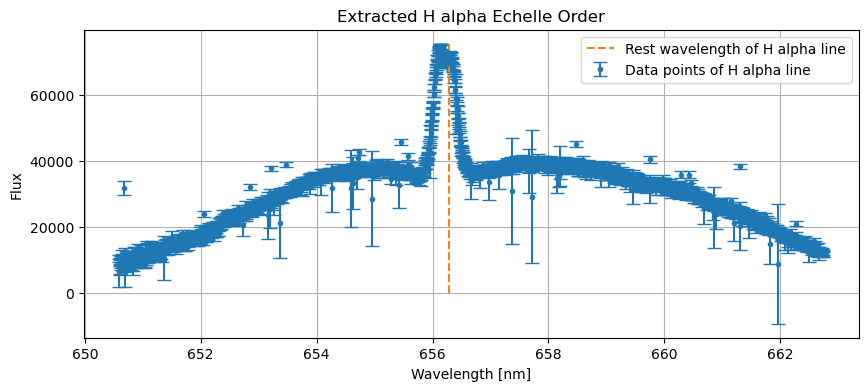

In [66]:
#convert wavelength to array with FLIPPED increasing order
alpha_wavelength = np.linspace(662.7470, 650.5864, 2048) #flipped

#create plot
plt.figure(figsize=(10,4))
plt.errorbar(alpha_wavelength, alpha_signal, yerr=error_alpha_signal, capsize= 5, fmt='.', label = 'Data points of H alpha line')
plt.plot((656.28,656.28), (0,75000), "--" , label = 'Rest wavelength of H alpha line')
plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux")
plt.title("Extracted H alpha Echelle Order")
plt.legend()
plt.grid()
plt.show()

As our spectral peak coincides with the published rest values of the $H_\alpha$ line we can infer that our plotting has been successful. 

### B.4: Repeat the steps for $H_\beta$ line

Let us now repeat tasks B.1 - B.3 but for the $H_\beta$ line. Let us start with appropriately slicing the row containing the $H_\beta$ line and two lines of background that are above and below our absorption line. 

Text(0, 0.5, 'y')

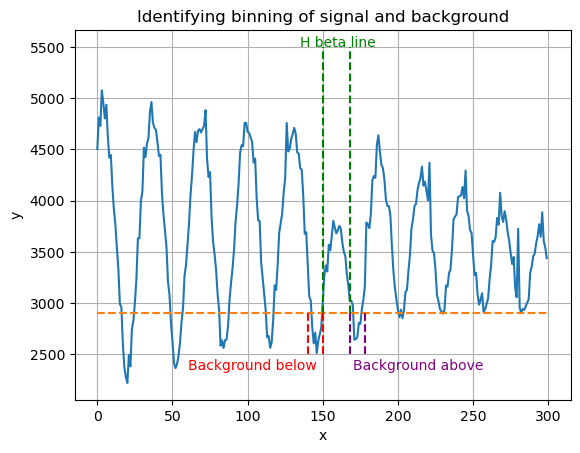

In [71]:
#determine size of binning for beta line

#plot the slice
plt.plot(av_image[1150:1450, 950])

#determine the threshold
plt.plot((0,300), (2900,2900), "--" , label = 'Threshold')


#find the width of h beta
plt.plot((150,150), (2900,5500), "--" , label = 'H alpha signal', color = 'green')
plt.plot((168,168), (2900,5500), "--" , label = 'H alpha signal', color = 'green')
plt.text(135, 5500, 'H beta line', color = 'green')


#find the width of background below 
plt.plot((140,140), (2500,2900), "--" , label = 'below signal', color = 'red')
plt.plot((150,150), (2500,2900), "--" , label = 'below signal', color = 'red')
plt.text(60, 2350, 'Background below', color = 'red')

#find the width of background above
plt.plot((168,168), (2500,2900), "--" , label = 'above signal', color = 'purple')
plt.plot((178,178), (2500,2900), "--" , label = 'above signal', color = 'purple')
plt.text(170, 2350, 'Background above', color = 'purple')

plt.grid()
plt.title ('Identifying binning of signal and background')
plt.xlabel('x')
plt.ylabel ('y')

According to this graph we pick the appropriate binning slices for the $H_\beta$ line and the above and below background. Here we take the background right by the spectral line rather than one away as the plot above shows us it would be rather hard to do. 

In [74]:
#selecting the H_beta line 
beta_eschelle = av_image [1300:1318, 0:2048] #y-axis first

#selecting the above background line 
beta_above = av_image [1318:1325, 0:2048]

#selecting the below background line 
beta_below = av_image [1295:1300, 0:2048]

Let us now plot our sliced areas on our FITS image, this time for both the $H_\alpha$ line and $H_\beta$ line and their chosen backgrounds. 

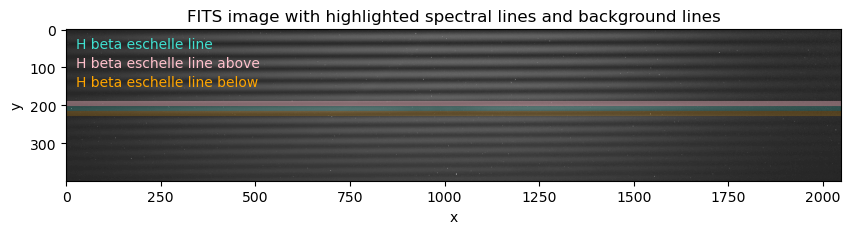

In [77]:
#define areas that we will plot

rect_beta = patches.Rectangle((0, 205), 2048, 5, linewidth=2, edgecolor='turquoise', alpha = 0.2, facecolor='none')
rect_beta_below = patches.Rectangle((0, 195), 2048, 2, linewidth=3, edgecolor='pink', alpha = 0.4, facecolor='none')
rect_beta_above = patches.Rectangle((0, 220), 2048, 2, linewidth=3, edgecolor='orange', alpha = 0.2, facecolor='none')

#select image slice
section_beta_line = av_image [1100:1500,] #y-coord first

#plotting our selected 
plt.figure (figsize= (10,20))
plt.imshow(section_beta_line, cmap='gray', vmin=vmin1 - 100, vmax=vmax1 - 5000)

#plot sections
plt.gca().add_patch(rect_beta)
plt.gca().add_patch(rect_beta_above)
plt.gca().add_patch(rect_beta_below)

#plt text
plt.text(25, 50, 'H beta eschelle line', color = 'turquoise')
plt.text(25, 100, 'H beta eschelle line above', color = 'pink')
plt.text(25, 150, 'H beta eschelle line below', color = 'orange')

plt.title ('FITS image with highlighted spectral lines and background lines')
plt.xlabel('x')
plt.ylabel ('y')
plt.show()

We now perform binning on our $H_\beta$ line and the chosen background lines by computing a vertical sum of each array:

In [80]:
#summing vertically 
beta_eschelle_sum = beta_eschelle.sum(axis = 0) #axis = 0 sums over y-axis 
beta_above_sum = beta_above.sum(axis = 0)
beta_below_sum = beta_below.sum(axis = 0)

#check the shape
print (beta_eschelle_sum.shape)

(2048,)


Background subtraction: 

In [83]:
#number of rows in our selected lines 
rows_beta = beta_eschelle.shape[0]
rows_beta_above = beta_above.shape[0]
rows_beta_below = beta_below.shape[0]

print (f"The number of rows in  the H beta line is {rows_beta}")
print (f"The number of rows in  the above background of the H beta line is {rows_beta_above}")
print (f"The number of rows in  the below background of the H beta line is {rows_beta_below}")


The number of rows in  the H beta line is 18
The number of rows in  the above background of the H beta line is 7
The number of rows in  the below background of the H beta line is 5


In [85]:
#computing the background

#find bg per row
bg_beta_above_per_row = beta_above_sum / rows_beta_above
bg_beta_below_per_row = beta_below_sum / rows_beta_below

#find median of the two 
bg_per_row_beta = np.median(np.vstack([bg_beta_above_per_row, bg_beta_below_per_row]), axis = 0)

#match number of rows in signal 
bg_scaled_beta = bg_per_row_beta * rows_beta

In [87]:
#subtracting background 
beta_signal = beta_eschelle_sum - bg_scaled_beta

#checking shape of array 
print (beta_signal.shape)

(2048,)


Using the same approach a for the $H_\alpha$ line, we calculate the errors on each data point:

In [90]:
#finding errors for h beta
err_signal_beta = np.sqrt (beta_eschelle_sum)
#err_b_beta = np.sqrt (bg_per_row_beta)
err_bg_above_b = np.std(beta_above, axis=0) / np.sqrt(rows_beta_above) 
err_bg_below_b = np.std(beta_below, axis=0) / np.sqrt(rows_beta_below)
err_b_beta = np.maximum (err_bg_above_b, err_bg_below_b)
error_beta_signal = np.sqrt(err_signal_beta**2 + (rows_beta * err_b_beta )**2)

Let us now plot our spectral line. We will expect to see an absorption dip centred around 486.1 nm [6]. Plotting our wavelength axis inversly, we obtain the following:

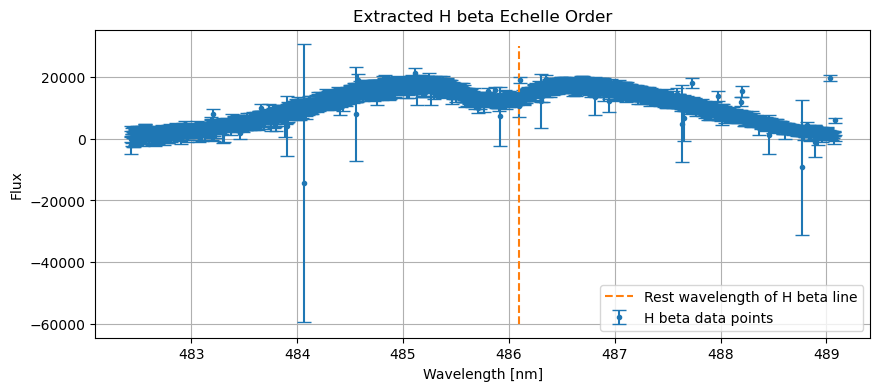

In [93]:
#convert wavelength to array with INVERSE increasing order
#beta_wavelength = np.linspace(482.426, 489.081, 2048)
beta_wavelength = np.linspace(489.081, 482.426, 2048)


#create plot
plt.figure(figsize=(10,4))
plt.errorbar(beta_wavelength, beta_signal, yerr=error_beta_signal, capsize= 5, fmt='.', label = "H beta data points")
plt.plot((486.1, 486.1), (-60000,30000), "--" , label = 'Rest wavelength of H beta line')
plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux")
plt.title("Extracted H beta Echelle Order")
plt.legend ()
plt.grid()
plt.show()

The spectral line is not necessarilly aligned with the rest wavelength as well as the $H_\alpha$ line is. We will make further comments on this when we calculate the doppler shift velocities of the lines in later sections of the task. Additionally we witness a couple of very large error bars, this could be due to cosmic rays.

## TASK C: Standard spectral analysis and identification of main line positions

### C.1: Normalization of continuum

In this section we will extract data points of the spectrum surrounding the spectral lines and excluding the spectral line itself as to plot a continuum fit. Again we start with $H_\alpha$ and then apply the same procedure for $H_\beta$. First let us zoom in on our spectral line so we can better identify the corresponding wavelengths.

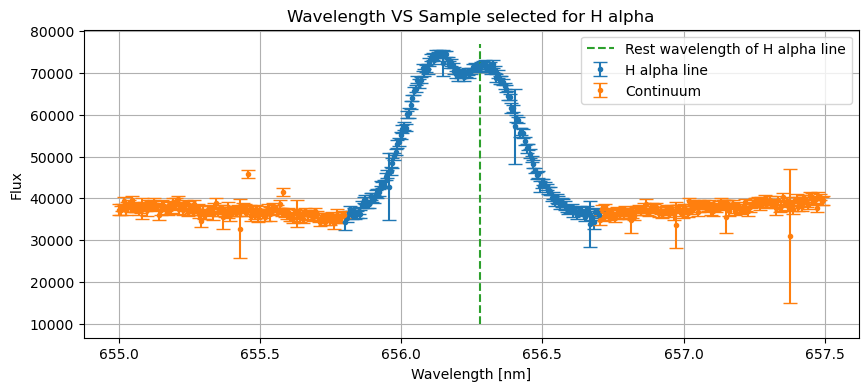

In [99]:
#using np.where to create a subset for H-alpha spectral line data
alpha_region = np.where (((655 < alpha_wavelength) & (alpha_wavelength < 657.5)))
continuum_alpha = np.where (((655 < alpha_wavelength) & (alpha_wavelength < 655.8)) | ((656.7 < alpha_wavelength) & (alpha_wavelength < 657.5)))
alpha_line = np.where (((655.8 < alpha_wavelength) & (alpha_wavelength < 656.7)))


#plot for visual confirmation
plt.figure(figsize=(10,4))
plt.errorbar(alpha_wavelength[alpha_line], alpha_signal[alpha_line], yerr=error_alpha_signal[alpha_line], capsize= 5, fmt='.', label = 'H alpha line')
plt.errorbar(alpha_wavelength[continuum_alpha], alpha_signal[continuum_alpha], yerr=error_alpha_signal[continuum_alpha], capsize= 5, fmt='.', label = 'Continuum')
plt.plot((656.28,656.28), (10000,77000), "--" , label = 'Rest wavelength of H alpha line')
plt.title('Wavelength VS Sample selected for H alpha')
plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux")
plt.grid()
plt.legend()

Having identified the data points of the continuum we will now plot a second degree fit to the data. We also recentre our data set in order to avoid errors arising in computation of errors in the future.

In [102]:
# recentre
x_0 = np.mean(alpha_wavelength[continuum_alpha])
print (x_0)
new_wavelength_alpha = alpha_wavelength[continuum_alpha] - x_0


656.2462026826819


Now we fit a second degree fit to the continuum: 

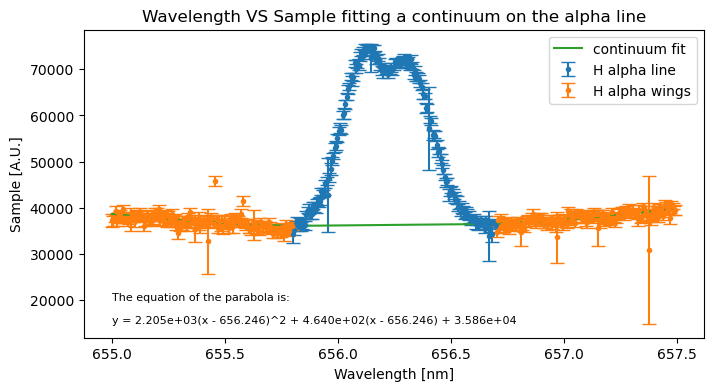

In [105]:
#np.polyfit
degree = 2
coeffs_alpha_cont, error_alpha_cont = np.polyfit (new_wavelength_alpha, alpha_signal[continuum_alpha], degree, w = 1/error_alpha_signal[continuum_alpha], cov = True)

#check the amount of coeffs found
len(coeffs_alpha_cont)

#unpack coeffs 
a_alpha_cont = coeffs_alpha_cont[0]
b_alpha_cont = coeffs_alpha_cont[1]
c_alpha_cont = coeffs_alpha_cont[2]

#unpack errors
a_alpha_error_con, b_alpha_error_con, c_alpha_error_con = np.sqrt(np.diag(error_alpha_cont)) 

#x-line for fit 
x_alpha_cont = alpha_wavelength[continuum_alpha]
x_alpha_cont_recentered = alpha_wavelength[continuum_alpha] - x_0
y_line_alpha_cont = (a_alpha_cont * x_alpha_cont_recentered  **2) + b_alpha_cont*x_alpha_cont_recentered   + c_alpha_cont

#plot
plt.figure(figsize=(8,4))
plt.errorbar(alpha_wavelength[alpha_line], alpha_signal[alpha_line], yerr=error_alpha_signal[alpha_line], capsize= 5, fmt='.', label = 'H alpha line')
plt.errorbar(alpha_wavelength[continuum_alpha], alpha_signal[continuum_alpha], yerr=error_alpha_signal[continuum_alpha], capsize= 5, fmt='.', label = "H alpha wings")
plt.plot (x_alpha_cont, y_line_alpha_cont, label = "continuum fit")
plt.title('Wavelength VS Sample fitting a continuum on the alpha line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(655, 20000,f"The equation of the parabola is:", fontsize = 8)
plt.text(655, 15000,f"y = {a_alpha_cont:.3e}(x - {x_0:.3f})^2 + {b_alpha_cont:.3e}(x - {x_0:.3f}) + {c_alpha_cont:.3e}",fontsize=8)
plt.legend()

In [107]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the alpha continuum are:")
print (f"a: {a_alpha_cont:.3f} ± {a_alpha_error_con:.3f}")
print (f"b: {b_alpha_cont:.3f} ± {b_alpha_error_con:.3f}")
print (f"c: {c_alpha_cont:.3f} ± {c_alpha_error_con:.3f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the alpha continuum are:
a: 2205.226 ± 152.901
b: 463.957 ± 68.764
c: 35859.081 ± 130.282


So our quadratic fit is in the form:
$$
y_{fit} = ax^2 + bx +c
$$

If we want to find the error $\Delta y_{fit}$ then we have to take the partial in respect to each and add them in quadrature[7]:

$$
\Delta y_{fit} =\sqrt{ \left(\frac{\partial y}{\partial a}\Delta_a\right)^2 + \left(\frac{\partial y}{\partial b}\Delta_b\right)^2 + \left(\frac{\partial y}{\partial c}\Delta_c\right)^2}
$$

Which gives:

$$
\Delta y_{fit} = \sqrt{(x^2 \Delta a)^2 + (x \Delta b)^2 + (\Delta c)^2}
$$



We will now normalise our continuum simply by:
$$
y_{norm} = \frac{y_{data}}{y_{fit}}
$$

The errors for the normalised continuum can be found by computing the partial derivatives and adding them in quadrature:

$$
\Delta y_{norm} = \sqrt{\left(\frac{\partial y_{norm}}{\partial y_{data}} \Delta y_{data}\right)^2 + \left(\frac{\partial y_{norm}}{\partial y_{fit}} \Delta y_{fit}\right)^2}
$$

Which gives:
$$
\Delta y_{norm} = \sqrt{\left(\frac{1}{y_{fit}} \Delta y_{data}\right)^2 + \left(\frac{- y_{data}}{y_{fit}^2} \Delta y_{fit}\right)^2}
$$


In [112]:
#to normalize we plug it into the model fitted 

#wavelength range 
alpha_wavelength_line = alpha_wavelength[alpha_region] 

# centered wavelength for evaluating the continuum model
x_cent = alpha_wavelength_line - x_0

# continuum model (correct)
y_fitted_alpha = ( a_alpha_cont * x_cent**2 + b_alpha_cont * x_cent + c_alpha_cont)

# normalised flux
y_normalized_alpha = alpha_signal[alpha_region] / y_fitted_alpha

#find errors for normalised continuum
#using x_cent:
y_fit_error_alpha = np.sqrt((x_cent**2 * a_alpha_error_con)**2 + (x_cent * b_alpha_error_con)**2 + (c_alpha_error_con)**2)

#y_fit_error_alpha = np.sqrt((alpha_wavelength[alpha_region]**2 * a_alpha_error_con)**2 + (x_alpha_cont * b_alpha_error_con)**2 + c_alpha_error_con**2)
y_alpha_region = alpha_signal[alpha_region]
y_line_alpha_cont = (a_alpha_cont * alpha_wavelength[alpha_region]  **2) + b_alpha_cont* alpha_wavelength[alpha_region]  + c_alpha_cont
err_y_norm_alpha = np.sqrt((error_alpha_signal[alpha_region] / y_line_alpha_cont)**2 + (y_alpha_region * y_fit_error_alpha / y_line_alpha_cont**2)**2)



Plotting our normalised data set:

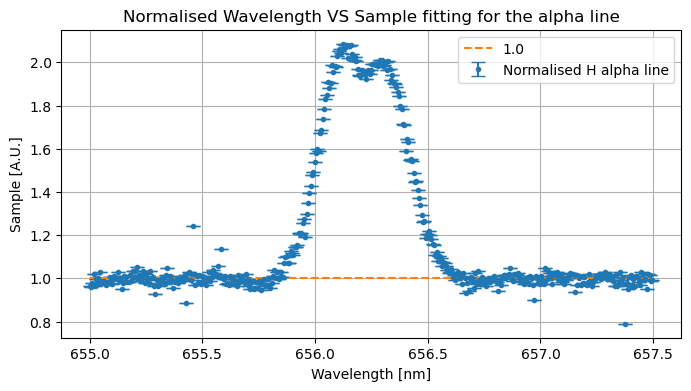

In [115]:
#plot wings which should be around 1 
plt.figure(figsize=(8,4))
#plt.errorbar(x_cent, y_normalized_alpha, yerr=err_y_norm_alpha , capsize= 5, fmt='.', label = "Normalised H alpha line")
plt.errorbar(alpha_wavelength_line, y_normalized_alpha, yerr=err_y_norm_alpha , capsize= 5, fmt='.', label = "Normalised H alpha line")

plt.title('Normalised Wavelength VS Sample fitting for the alpha line')
plt.plot((655,657.5), (1,1), "--" , label = '1.0')
plt.grid({'x'})
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

The wings of our fit are around ~1 showing that our line was sucessfully normalised. We can now proceed to fit our line with a second degree fit. 

### C.2: Line peak fits 

We will now fit a second-order polynomial fit to the normalised $H_\alpha$ line. Let us first limit the range of the wavelength to just the spectral line:

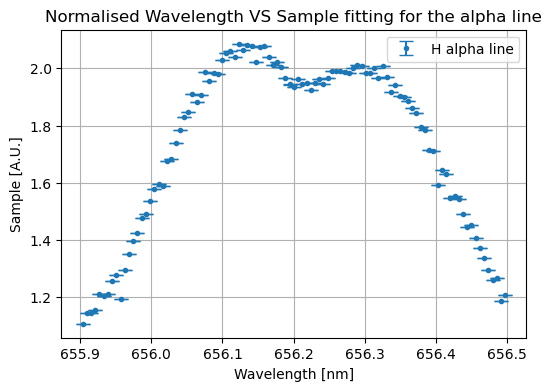

In [125]:
#limiting the range using np.where 
alpha_line_id = np.where((655.9 < alpha_wavelength_line) & (alpha_wavelength_line < 656.5)) [0]
alpha_line_wavelength = alpha_wavelength_line[alpha_line_id]
alpha_line_y_normalised = y_normalized_alpha[alpha_line_id]


#plot 
plt.figure(figsize=(6,4))
plt.errorbar(alpha_line_wavelength, alpha_line_y_normalised, yerr=err_y_norm_alpha[alpha_line_id] , capsize= 5, fmt='.', label = 'H alpha line')
plt.title('Normalised Wavelength VS Sample fitting for the alpha line')
plt.grid({'x'})
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

Now we will fit a second degree open down parabola in order to obtain the coeffiecient of this equation and hence find the peak of the spectral line. 

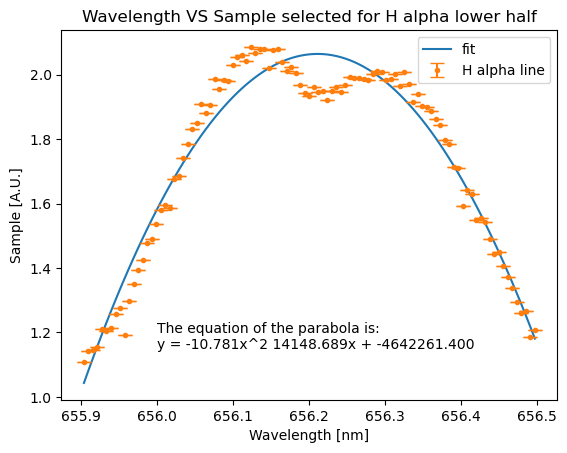

In [128]:
#np.polyfit
degree = 2
#recentre 
coeffs_alpha, error_alpha = np.polyfit (alpha_line_wavelength, alpha_line_y_normalised, degree, w = 1/(err_y_norm_alpha[alpha_line_id]), cov = True)

#unpack coeffs 
a_alpha = coeffs_alpha[0]
b_alpha= coeffs_alpha[1]
c_alpha = coeffs_alpha[2]

#unpack errors
a_alpha_error, b_alpha_error, c_alpha_error = np.sqrt(np.diag(error_alpha)) 

#lines for fit 
x_alpha= alpha_line_wavelength
y_line_alpha = (a_alpha * alpha_line_wavelength**2) + b_alpha*alpha_line_wavelength + c_alpha

#plot
plt.plot (x_alpha, y_line_alpha, label = "fit")
plt.errorbar(alpha_line_wavelength, alpha_line_y_normalised, yerr=err_y_norm_alpha[alpha_line_id] , capsize= 5, fmt='.', label = 'H alpha line')
plt.title('Wavelength VS Sample selected for H alpha lower half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(656, 1.2,f"The equation of the parabola is:")
plt.text(656, 1.15,f"y = {a_alpha:.3f}x^2 {b_alpha:.3f}x + {c_alpha:.3f}")
plt.legend()

In [130]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the polynomial fit of the H alpha are:")
print (f"a: {a_alpha:.5f} ± {a_alpha_error:.5f}")
print (f"b: {b_alpha:.5f} ± {b_alpha_error:.5f}")
print (f"c: {c_alpha:.5f} ± {c_alpha_error:.5f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the polynomial fit of the H alpha are:
a: -10.78059 ± 0.19760
b: 14148.68924 ± 259.32514
c: -4642261.40004 ± 85084.39019


Lastly, we calculate the vertex of the fit by using: 
$$
x_v = \frac{-b}{2a}
$$
One could assume, we propagate the calculated errors to the value of the vertex too by taking the partial derivative and adding in quadrature:
$$
\Delta x_{v} = \sqrt{\frac{\Delta b^2}{4a^2} + \frac{b^2 \Delta a^2}{4 a^4}}
$$
Nevertheless, if we compute the errors this way we obtain an error that seems unphysical compared to our later calculated value of wavelength and recession velocity. This is most likely because we drop the covariance term as we assume the fit to have uncorrelated measurements. If we compute the covariance, we find that:

In [133]:
#extract covariance between variables
cov_ab = error_alpha[0,1] 
print (cov_ab)

-51.24174738111472


The value is negative which answers why we get extremely large error values if we ignore the covariance term. Our error propagation is hence transformed to [8]:
$$
\Delta x_{v} = \sqrt{\frac{\Delta b^2}{4a^2} + \frac{b^2 \Delta a^2}{4 a^4} + 2  \frac{-1}{2a}* \frac{b}{2a^2} cov(a,b)}
$$


In [141]:
#searching for the vertex of H alpha
vertex_alpha = (-b_alpha) / (2*a_alpha)

#find error accounting for cov
vertex_err_alpha = np.sqrt(((b_alpha / (2 * a_alpha**2))**2) * (a_alpha_error**2) + ((-1 / (2 * a_alpha))**2) * (b_alpha_error**2) + 2 * (b_alpha / (2 * a_alpha**2)) * (-1 / (2 * a_alpha)) * cov_ab)
print (f"The exact position of the H alpha line is: {vertex_alpha:.5f} ± {vertex_err_alpha:.5f} nm")


The exact position of the H alpha line is: 656.21110 ± 0.00172 nm


Before we find the relative velocity of Alcyone, let us find the correction for the heliospheric velocity, we will need to find the time of observation from the header:

In [144]:
#from the header of one of the images 
print (f"Time of observation: {header1['DATE-OBS']}")

Time of observation: 2023-01-24T21:10:03


Additionally, we will need the location of the UCL Observatory. By a quick wikipedia search, we find the location to be 51°36′48.24″N,  0°14′31.2″W [9] which will need to be converted to decimal degrees. Furthermore we need the RA and Dec of Alcyone which is stated by SIMBAD to be RA: 3h47m29.0765529s and Dec: +24d06m18.488347s [10].

In [147]:
#heliocentric correction 
#time
obs_time = Time('2023-01-24T21:10:03') 

#long and lat
lat = 51 + 36/60 + 48.24/3600
longt = (14/60 + 31.2/3600) * -1
loc = EarthLocation(lat=lat*u.deg, lon=longt*u.deg, height=46*u.m)

#coords of star 
star = SkyCoord(ra='03h47m29.0765529s', dec='+24d06m18.488347s', frame='icrs')

v_corr = star.radial_velocity_correction( kind='heliocentric', obstime=obs_time,location=loc)

#convert to km/s from AU/day
v_corr_kms = v_corr.to(u.km/u.s)

print (f"The correction velocity for Alcyone is {v_corr_kms:.3f}")

The correction velocity for Alcyone is -27.234 km / s


We can now compute the relative velocity of Alcyone through the $H_\alpha$ line:

$$
v_{\alpha} = \frac{c \Delta \lambda_{\alpha}}{\lambda_0} 
$$

Where:
- c = speed of light
- $\Delta \lambda_{\alpha}$ = difference in rest and the computed vertex wavelength 
- $\lambda_0$ = rest wavelength (= 656.28 nm [6])

The error for $\Delta v_{\alpha}$ is propagated and added in quadrature to give:
$$
\Delta v_{\alpha} = \frac{c}{\lambda_{0}} * \Delta \lambda_{\alpha}
$$


In [150]:
# relative velocity of Alcyone from h alpha line 
c = 3*10**8
h_alpha_rest = 656.28

velocity_Alcyone_alpha = ((c * (h_alpha_rest - vertex_alpha)) / (h_alpha_rest) /1000)
error_velocity_Alcyone_alpha = (((c/h_alpha_rest) * vertex_err_alpha) /1000)

print (f"The speed of Alcyone from the H alpha line is: {velocity_Alcyone_alpha:.3f} ± {error_velocity_Alcyone_alpha:.3f} km/s")

The speed of Alcyone from the H alpha line is: 31.496 ± 0.788 km/s


Ultimately we subtract the correction velocity: 
$$
v = v_{\alpha} + v_{corrected}
$$

In [153]:
#final velocity for alpha line 
v_alpha_final = velocity_Alcyone_alpha + v_corr_kms.value
print (f"The final speed (accounted for heliospheric correction) of Alcyone from the H alpha line is: {v_alpha_final:.3f} ± {error_velocity_Alcyone_alpha:.3f} km/s")

The final speed (accounted for heliospheric correction) of Alcyone from the H alpha line is: 4.262 ± 0.788 km/s


According to our doppler velocity calculation, we infer that Alcyone is redshifted. 

### C.3: Repeat spectral analysis for $H_\beta$

Let us start with picking a part of the $H_\beta$ line and identify point that correspond to the continuum and the spectral line:

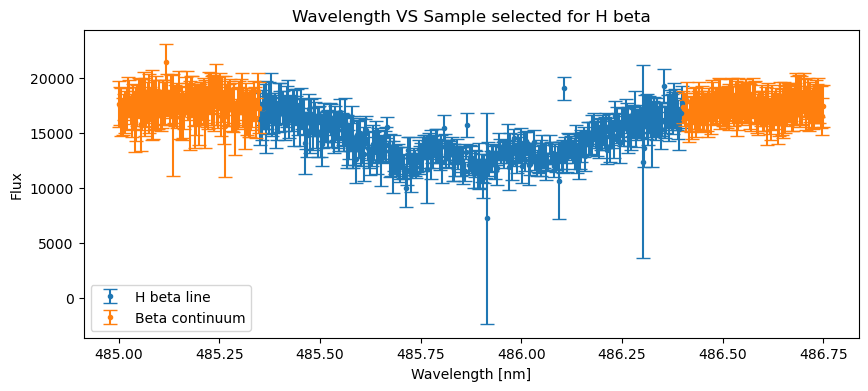

In [158]:
#using np.where to create a subset for H-alpha spectral line data
beta_region = np.where (((485 < beta_wavelength) & (beta_wavelength < 486.75)))
continuum_beta = np.where (((485 < beta_wavelength) & (beta_wavelength < 485.35)) | ((486.4 < beta_wavelength) & (beta_wavelength < 486.75)))
beta_line = np.where (((485.35 < beta_wavelength) & (beta_wavelength < 486.4)))


#plot for visual confirmation
plt.figure(figsize=(10,4))
plt.errorbar(beta_wavelength[beta_line], beta_signal[beta_line], yerr=error_beta_signal[beta_line], capsize= 5, fmt='.', label = 'H beta line')
plt.errorbar(beta_wavelength[continuum_beta], beta_signal[continuum_beta], yerr=error_beta_signal[continuum_beta], capsize= 5, fmt='.', label = 'Beta continuum')
plt.title('Wavelength VS Sample selected for H beta')
plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux")
plt.legend()

Having identified the data points of the continuum we will now plot a second degree fit to the data. Before we fit our continuum, we will re-centre our fit just like we did in for $H_\alpha$.

In [161]:
# recentre for h beta
x_0_beta = np.mean(beta_wavelength[continuum_beta])
print (x_0_beta)
new_wavelength_beta = beta_wavelength[continuum_beta] - x_0_beta

485.87541621885686


Now we fit a second degree fit to the continuum of $H_\beta$:

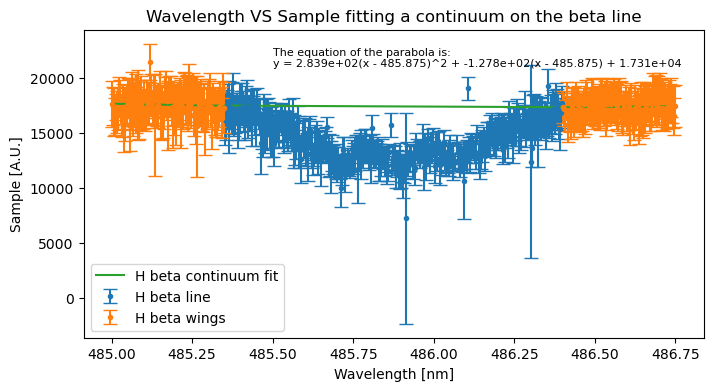

In [164]:
#np.polyfit
degree = 2
coeffs_beta_cont, error_beta_cont = np.polyfit (new_wavelength_beta, beta_signal[continuum_beta], degree, w = 1/error_beta_signal[continuum_beta], cov = True)

#check the amount of coeffs found
len(coeffs_beta_cont)

#unpack coeffs 
a_beta_cont = coeffs_beta_cont[0]
b_beta_cont = coeffs_beta_cont[1]
c_beta_cont = coeffs_beta_cont[2]

#unpack errors
a_beta_error_con, b_beta_error_con, c_beta_error_con = np.sqrt(np.diag(error_beta_cont)) 

#x-line for fit 
x_beta_cont = beta_wavelength[continuum_beta]
x_beta_cont_recentered = beta_wavelength[continuum_beta] - x_0_beta
y_line_beta_cont = (a_beta_cont * x_beta_cont_recentered  **2) + b_beta_cont*x_beta_cont_recentered   + c_beta_cont

#plot
plt.figure(figsize=(8,4))
plt.errorbar(beta_wavelength[beta_line], beta_signal[beta_line], yerr=error_beta_signal[beta_line], capsize= 5, fmt='.', label = 'H beta line')
plt.errorbar(beta_wavelength[continuum_beta], beta_signal[continuum_beta], yerr=error_beta_signal[continuum_beta], capsize= 5, fmt='.', label = "H beta wings")
plt.plot (x_beta_cont, y_line_beta_cont, label = "H beta continuum fit")
plt.title('Wavelength VS Sample fitting a continuum on the beta line')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(485.5, 22000,f"The equation of the parabola is:", fontsize = 8)
plt.text(485.5, 21000,f"y = {a_beta_cont:.3e}(x - {x_0_beta:.3f})^2 + {b_beta_cont:.3e}(x - {x_0_beta:.3f}) + {c_beta_cont:.3e}",fontsize=8)
plt.legend()

In [166]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the beta continuum are:")
print (f"a: {a_beta_cont:.3f} ± {a_beta_error_con:.3f}")
print (f"b: {b_beta_cont:.3f} ± {b_beta_error_con:.3f}")
print (f"c: {c_beta_cont:.3f} ± {c_beta_error_con:.3f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the fit of the beta continuum are:
a: 283.949 ± 335.591
b: -127.825 ± 68.149
c: 17307.296 ± 173.424


We propagate our errors the same way as we did with the $H_\alpha$ continuum in part C.1: 

In [169]:
# error propagation for the y continuum fit for beta line:
y_fit_error_beta = np.sqrt((beta_wavelength[beta_region]**2 * a_beta_error_con)**2 + (beta_wavelength[beta_region] * b_beta_error_con)**2 + c_beta_error_con**2)

#find errors for normalised continuum
y_beta_region = beta_signal[beta_region]
y_line_beta_cont = (a_beta_cont * beta_wavelength[beta_region]  **2) + b_beta_cont* beta_wavelength[beta_region]  + c_beta_cont
err_y_norm_beta = np.sqrt((error_beta_signal[beta_region] / y_line_beta_cont)**2 + (y_beta_region * y_fit_error_beta / y_line_beta_cont**2)**2)


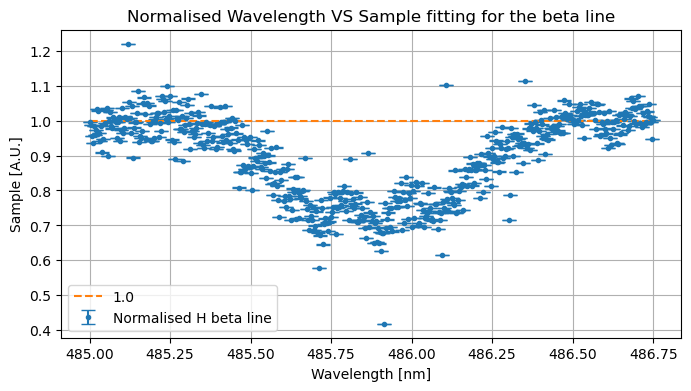

In [171]:
#to normalize we plug it into the model fitted 

#wavelength range 
beta_wavelength_line = beta_wavelength[beta_region]

# centered wavelength for evaluating the continuum model
x_cent_beta = beta_wavelength_line - x_0_beta

# continuum model (correct)
y_fitted_beta = ( a_beta_cont * x_cent_beta**2 + b_beta_cont * x_cent_beta + c_beta_cont)

# normalised flux
y_normalized_beta = beta_signal[beta_region] / y_fitted_beta

#plot wings which should be around 1 
plt.figure(figsize=(8,4))
plt.errorbar(beta_wavelength_line, y_normalized_beta, yerr=err_y_norm_beta , capsize= 5, fmt='.', label = "Normalised H beta line")
plt.title('Normalised Wavelength VS Sample fitting for the beta line')
plt.plot((485,486.75), (1,1), "--" , label = '1.0')
plt.grid({'x'})
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

Normalisation was sucessful, as the wings are around ~1.0.

We will now fit a second-order polynomial fit to the normalised $H_\beta$ line. Let us first limit the range of the wavelength to just the spectral line:

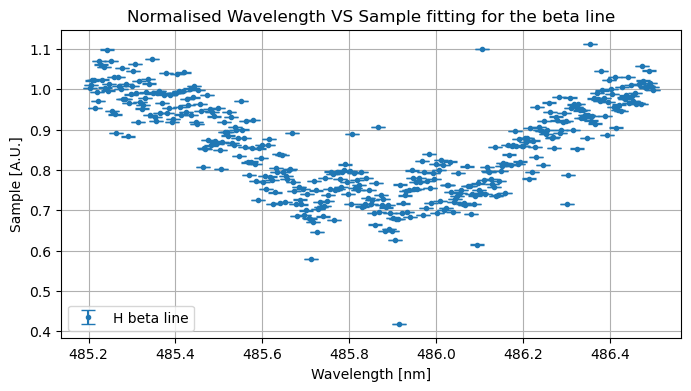

In [175]:
#limiting the range using np.where 
beta_line_id = np.where((485.2 < beta_wavelength_line) & (beta_wavelength_line < 486.5)) [0]
beta_line_wavelength = beta_wavelength_line[beta_line_id]
beta_line_y_normalised = y_normalized_beta[beta_line_id]


#plot 
plt.figure(figsize=(8,4))
plt.errorbar(beta_line_wavelength, beta_line_y_normalised, yerr=err_y_norm_beta[beta_line_id] , capsize= 5, fmt='.', label = 'H beta line')
plt.title('Normalised Wavelength VS Sample fitting for the beta line')
plt.grid({'x'})
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.legend()

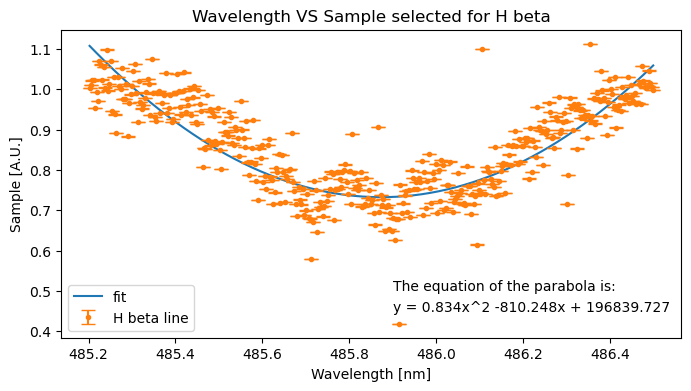

In [177]:
#np.polyfit for a second degree fit 
degree = 2
coeffs_beta, error_beta = np.polyfit (beta_line_wavelength,beta_line_y_normalised, degree, w = 1/err_y_norm_beta[beta_line_id], cov = True)

#unpack coeffs 
a_beta = coeffs_beta[0]
b_beta= coeffs_beta[1]
c_beta = coeffs_beta[2]

#unpack errors
a_beta_error, b_beta_error, c_beta_error = np.sqrt(np.diag(error_beta)) 

#lines for fit 
x_beta= beta_line_wavelength
y_line_beta = (a_beta * beta_line_wavelength**2) + b_beta*beta_line_wavelength + c_beta

#plot
plt.figure(figsize=(8,4))
plt.plot (x_beta, y_line_beta, label = "fit")
plt.errorbar(beta_line_wavelength,beta_line_y_normalised, yerr=err_y_norm_beta[beta_line_id] , capsize= 5, fmt='.', label = 'H beta line')
plt.title('Wavelength VS Sample selected for H beta')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.text(485.9, 0.5, f"The equation of the parabola is:")
plt.text(485.9, 0.45, f"y = {a_beta:.3f}x^2 {b_beta:.3f}x + {c_beta:.3f}")
plt.legend()

In [179]:
#let's also print the value of the coefficients and their errors below
print (f"For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the polynomial fit of the H beta are:")
print (f"a: {a_beta:.5f} ± {a_beta_error:.5f}")
print (f"b: {b_beta:.5f} ± {b_beta_error:.5f}")
print (f"c: {c_beta:.5f} ± {c_beta_error:.5f}")

For the quadratic equation in form y = ax^2 + bx +c the coefficients found by the polynomial fit of the H beta are:
a: 0.83381 ± 0.02609
b: -810.24787 ± 25.35273
c: 196839.72717 ± 6158.87092


Lastly, we calculate the vertex of the fit by using: 
$$
x_v = \frac{-b}{2a}
$$
Additionally, we propagate the calculated errors to the value of the vertex by the same method adapted for the $H_\alpha$ line including the consideration of the covariance matrix in our error propagation.

In [182]:
#searching for the vertex of H alpha
vertex_beta = (-b_beta) / (2*a_beta)

#error on gamma vertex
cov_ab_beta = error_beta[0,1] 
vertex_err_beta = np.sqrt(((b_beta / (2 * a_beta**2))**2) * (a_beta_error**2) + ((-1 / (2 * a_beta))**2) * (b_beta_error**2) + 2 * (b_beta / (2 * a_beta**2)) * (-1 / (2 * a_beta)) * cov_ab_beta)

#vertex_err_beta = np.sqrt ((b_beta_error**2)/(4*a_beta**2) + ((b_beta**2)*(a_beta_error**2))/ (4*a_beta**4))

print (f"The exact position of the H beta line is: {vertex_beta:.5f} ± {vertex_err_beta:.5f} nm")


The exact position of the H beta line is: 485.87352 ± 0.00551 nm


We can now compute the relative velocity of Alcyone for the $H_\beta$ line using:

$$
v_{\beta} = \frac{c \Delta \lambda_{\beta}}{\lambda_0} 
$$

Where:
- c = speed of light
- $\Delta \lambda_{\beta}$ = difference in rest and the computed vertex wavelength 
- $\lambda_0$ = rest wavelength (= 486.1 nm [6])

The error for $\Delta v_{\beta}$ is propagated and added in quadrature to give:
$$
\Delta v_{\beta} = \frac{c}{\lambda_{0}} * \Delta \lambda_{\beta}
$$


In [185]:
# relative velocity of Alcyone from h alpha line 
c = 3*10**8
h_beta_rest = 486.1

velocity_Alcyone_beta = ((c * (h_beta_rest - vertex_beta)) / (h_beta_rest) /1000)
error_velocity_Alcyone_beta = (((c/h_beta_rest) * vertex_err_beta) /1000)

print (f"The speed of Alcyone from the H beta line is: {velocity_Alcyone_beta:.3f} ± {error_velocity_Alcyone_beta:.3f} km/s")

The speed of Alcyone from the H beta line is: 139.771 ± 3.402 km/s


Ultimately we subtract the correction velocity we calculated in the previous section: 
$$
v = v_{\alpha} + v_{corrected}
$$

In [188]:
#final velocity for alpha line 
v_beta_final = velocity_Alcyone_beta + v_corr_kms.value
print (f"The final speed (accounted for heliospheric correction) of Alcyone from the H beta line is: {v_beta_final:.3f} ± {error_velocity_Alcyone_beta:.3f} km/s")

The final speed (accounted for heliospheric correction) of Alcyone from the H beta line is: 112.536 ± 3.402 km/s


According to our doppler velocity calculation, we infer that Alcyone is redshifted. 

### C.4: Summary of obtained wavelengths and doppler velocities 

In this section let us briefly summarize our findings in a table:

In [193]:
#output results as a table 
our_wavelengths = [vertex_alpha, vertex_beta]
our_wavelengths_rounded = np.round(our_wavelengths, 3)
our_wavelengths_err = [vertex_err_alpha, vertex_err_beta]
our_wavelengths_err_rounded = np.round(our_wavelengths_err, 3)
doppler_speeds = [v_alpha_final, v_beta_final]
doppler_speeds_rounded = np.round(doppler_speeds, 3)
doppler_err = [error_velocity_Alcyone_alpha, error_velocity_Alcyone_beta]
doppler_err_rounded = np.round(doppler_err, 3)


#make output as pandas dataframe
df_results_section_c = pd.DataFrame ({"Literature value of λ" : [656.28, 486.1], 
                            "Our values of  λ [nm]": our_wavelengths_rounded,
                            "Δ λ [nm]": our_wavelengths_err_rounded,
                            "Doppler speeds v [km/s]": doppler_speeds_rounded,
                            "Δv [km/s]": doppler_err_rounded},
                           index = ['H_α', 'H_β'])
df_results_section_c

,Literature value of λ,Our values of λ [nm],Δ λ [nm],Doppler speeds v [km/s],Δv [km/s]
H_α,656.28,656.211,0.002,4.262,0.788
H_β,486.10,485.874,0.006,112.536,3.402


The discrepancy between the radial doppler speeds of the two lines is rather large. This might arise from our method of using a basic second degree np.polyfit() for a rather complex pair of lines. In further sections we will see if this is a limitation of our chosen method or there is something else going on that yields this large discrepancy. 

## TASK D: Using a Monte Carlo approach to perform complex fitting

### D.1: Fit of $H_\alpha$ 

For this section of the task, we will use Monte Carlo simulations to find fit parameters of our spectral lines. Although our spectral lines consist of numerous features, we will attempt to fit the by a combination of Gaussian curves. Hence below we define a simple Gaussian curve [11]:
$$y = A \exp \left[-\frac{(x-\bar{x})^2}{2\sigma^2}\right] $$
Where:
- A = amplitude 
- x = array of x-values
- $\bar{x}$ = mean (position)
- $\sigma$ = standard deviation (width)

In [202]:
def gaussian(x, amplitude, position, width):
    '''A basic function that calculates the Gaussian of a data set using the formula stated above
    Inputs: a = amplitude
            x = array
            position = mean value / position
            s = standard deviation /width
    Returns: y = Gaussian curve'''
    
    y = amplitude*np.exp(-((x - position)**2)/(2*width**2))
    return y

Now we use the function to fit certain regions of the H-alpha line to figure out which features we want to fit. We will use one Gaussian with a positive amplitude to show the overall emission peak and then one Gaussin with a negative amplitude to account for the small "dent" in our emeission line:

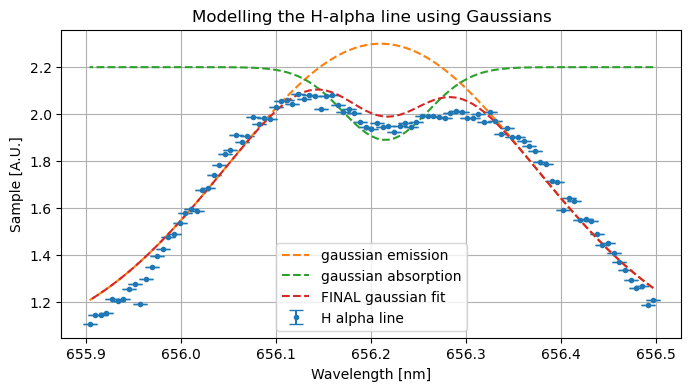

In [205]:
#fitting the gaussians:
gauss_emission = gaussian (alpha_line_wavelength, 1.3, 656.21, 0.16) + 1
gauss_dip = gaussian(alpha_line_wavelength, -0.31, 656.215, 0.045) + 2.2
fit_gauss = gauss_emission + gauss_dip - 2.2

#plot
plt.figure(figsize=(8,4))
plt.errorbar(alpha_line_wavelength, alpha_line_y_normalised, yerr=err_y_norm_alpha[alpha_line_id] , capsize= 5, fmt='.', label = 'H alpha line')
plt.plot (alpha_line_wavelength,gauss_emission, "--", label = "gaussian emission")
plt.plot (alpha_line_wavelength,gauss_dip, "--", label = "gaussian absorption")
plt.plot (alpha_line_wavelength,fit_gauss, "--", label = "FINAL gaussian fit")


plt.title('Modelling the H-alpha line using Gaussians')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid()
plt.legend()

Hence for our $H_{alpha}$ line we will be modelling two Gaussian which once added will yield our fit encapsulating both the emission peak and dent. We store our "guessed" values that we obatined through this fitting:

In [208]:
#saving our estimates from the fits above
amplitude_alpha_emission = 1.3
position_alpha_emission = 656.21
width_alpha_emission = 0.16

amplitude_alpha_dent= -0.31
position_alpha_dent = 656.215
width_alpha_dent = 0.045

### D.2: Monte Carlo setup

We will run a Monte Carlo simulation to estimate the amplitude, mean and standard deviation of each of the two Gaussians that we are fitting, ultimately giving us 6 fit parameters. As visualised above, once we add these two gaussians, we will obtain a suitable approximation for the curve. We will compute the least squares residuals (LSR) which are given by:
$$
LSR = \sum (y_{i} - y_{fit})^2
$$

Additionally, we will also compute $\chi ^2$ using [8]:
$$
\chi ^2 = \sum_{i}^{N} \frac{(y_{i} - y_{fit})^2}{\Delta y_{i}}
$$
As we are ultimatley fitting a curve of combined Gaussians, plotting our parameters and minimising them according to $\chi ^2$ will prove to be more suitable as it takes into account the goodness of the fit. 

In [223]:
# monte carlo simulations set up from week 5
n = 1000

#define empty arrays
amplitude_a_emission_mc =np.array([])
position_a_emission_mc = np.array([])
width_a_emission_mc = np.array([])

amplitude_a_abs_mc =np.array([])
position_a_abs_mc = np.array([])
width_a_abs_mc = np.array([])

LSR_alpha_mc = np.array ([])
chi2_alpha_mc = np.array ([])

#loop
for x in range (n):
    amplitude_em_run = random.uniform(amplitude_alpha_emission * 0.8, amplitude_alpha_emission * 1.2)
    position_em_run = random.uniform(position_alpha_emission - 0.05, position_alpha_emission + 0.05)
    width_em_run = random.uniform(width_alpha_emission - 0.05, width_alpha_emission + 0.05)
    
    amplitude_abs_run = random.uniform(amplitude_alpha_dent * 0.8, amplitude_alpha_dent * 1.2)
    position_abs_run = random.uniform(position_alpha_dent - 0.05, position_alpha_dent + 0.05)
    width_abs_run = random.uniform(width_alpha_dent - 0.05, width_alpha_dent + 0.05)

    #gaussian
    mc_gauss1 = gaussian(alpha_line_wavelength, amplitude_em_run, position_em_run, width_em_run)
    mc_gauss2 = gaussian(alpha_line_wavelength, amplitude_abs_run, position_abs_run, width_abs_run)

    #final fit 
    fit_alpha_mc = mc_gauss1 + mc_gauss2 + 1
    
    #lSR & chi2
    LSR_alpha_run =np.sum((alpha_line_y_normalised - fit_alpha_mc)**2)
    chi2_alpha_run = np.sum (((alpha_line_y_normalised - fit_alpha_mc)**2) / (err_y_norm_alpha[alpha_line_id])**2)
    
    #append
    amplitude_a_emission_mc = np.append(amplitude_a_emission_mc, amplitude_em_run)
    position_a_emission_mc = np.append(position_a_emission_mc, position_em_run)
    width_a_emission_mc = np.append(width_a_emission_mc, width_em_run)
    
    amplitude_a_abs_mc = np.append(amplitude_a_abs_mc, amplitude_abs_run)
    position_a_abs_mc = np.append(position_a_abs_mc, position_abs_run)
    width_a_abs_mc = np.append(width_a_abs_mc, width_abs_run)

    LSR_alpha_mc = np.append (LSR_alpha_mc, LSR_alpha_run)
    chi2_alpha_mc = np.append(chi2_alpha_mc, chi2_alpha_run)

    

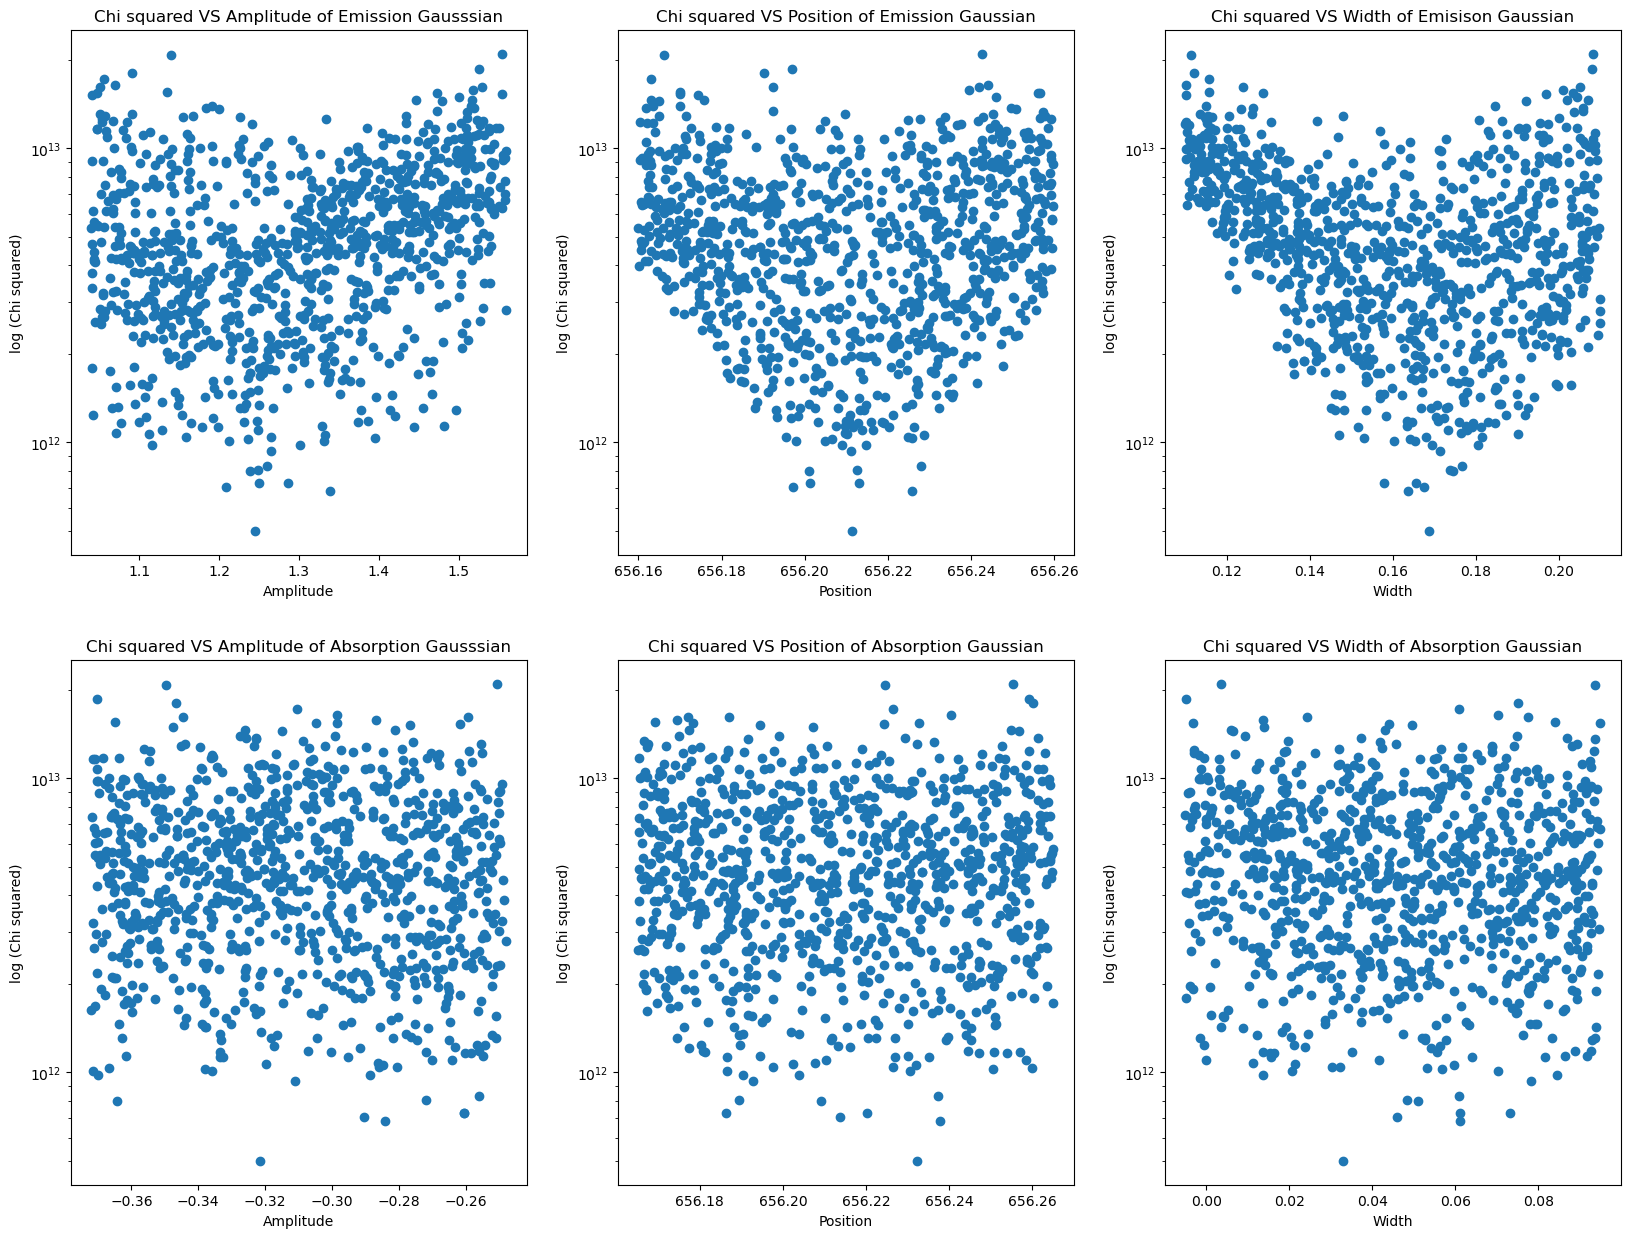

In [225]:
#parameters VS chi sq subplots
fig, ax = plt.subplots(2,3, figsize=(20,15))
ax[0,0].scatter(amplitude_a_emission_mc, chi2_alpha_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('Chi squared VS Amplitude of Emission Gausssian')
ax[0,0].set_xlabel ('Amplitude')
ax[0,0].set_ylabel ('log (Chi squared)')

ax[0,1].scatter(position_a_emission_mc, chi2_alpha_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('Chi squared VS Position of Emission Gaussian')
ax[0,1].set_xlabel ('Position')
ax[0,1].set_ylabel ('log (Chi squared)')

ax[0,2].scatter(width_a_emission_mc , chi2_alpha_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('Chi squared VS Width of Emisison Gaussian')
ax[0,2].set_xlabel ('Width')
ax[0,2].set_ylabel ('log (Chi squared)')

ax[1,0].scatter(amplitude_a_abs_mc, chi2_alpha_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('Chi squared VS Amplitude of Absorption Gausssian')
ax[1,0].set_xlabel ('Amplitude')
ax[1,0].set_ylabel ('log (Chi squared)')

ax[1,1].scatter(position_a_abs_mc, chi2_alpha_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('Chi squared VS Position of Absorption Gaussian')
ax[1,1].set_xlabel ('Position')
ax[1,1].set_ylabel ('log (Chi squared)')

ax[1,2].scatter(width_a_abs_mc, chi2_alpha_mc)
ax[1,2].set_yscale('log')
ax[1,2].set_title ('Chi squared VS Width of Absorption Gaussian')
ax[1,2].set_xlabel ('Width')
ax[1,2].set_ylabel ('log (Chi squared)')
plt.savefig("H_alpha MC, chi sq, n=1000")

Hence for our initial Monte Carlo set up for n = 1000, we obtain:
![H_alpha MC n=1000](<H_alpha MC, chi sq, n=1000.png>)                                 

Increasing the number of iterations to n = 10000, we obtain:
![H_alpha MC n=10000](<H_alpha MC, chi sq, n=10000.png>)

Let us now fine tune our results so we can obtain values for our simulated parameters.

### D.3: Fine tuning

Having obtained subplots for each of our parameters in the previous part, we will now attempt to "fine-tune" our range estimates to gain a LSR based on our $\chi ^2$ which represent all fitted parameters equally and are not biased to a single paramter. Let us attempt to "zoom in" on our ranges now to obtain more uniform subplots. 

In [251]:
# monte carlo simulations set up from week 5'
n = 10000

#define empty arrays
amplitude_a_emission_mc =np.array([])
position_a_emission_mc = np.array([])
width_a_emission_mc = np.array([])

amplitude_a_abs_mc =np.array([])
position_a_abs_mc = np.array([])
width_a_abs_mc = np.array([])

LSR_alpha_mc = np.array ([])
chi2_alpha_mc = np.array ([])

#loop
for x in range (n):
    
    amplitude_em_run = random.uniform(amplitude_alpha_emission * 0.85, amplitude_alpha_emission * 1.15)
    position_em_run = random.uniform(position_alpha_emission - 0.02, position_alpha_emission + 0.02)
    width_em_run = random.uniform(width_alpha_emission - 0.02, width_alpha_emission + 0.02)
    
    amplitude_abs_run = random.uniform(amplitude_alpha_dent * 0.8, amplitude_alpha_dent * 1.2)
    position_abs_run = random.uniform(position_alpha_dent - 0.05, position_alpha_dent + 0.05)
    width_abs_run = random.uniform(width_alpha_dent - 0.05, width_alpha_dent + 0.05)

    #gaussian
    mc_gauss1 = gaussian(alpha_line_wavelength, amplitude_em_run, position_em_run, width_em_run)
    mc_gauss2 = gaussian(alpha_line_wavelength, amplitude_abs_run, position_abs_run, width_abs_run)

    #final fit 
    fit_alpha_mc = mc_gauss1 + mc_gauss2 + 1
    
    #lSR & chi2
    LSR_alpha_run =np.sum((alpha_line_y_normalised - fit_alpha_mc)**2)
    chi2_alpha_run = np.sum (((alpha_line_y_normalised - fit_alpha_mc)**2) / (err_y_norm_alpha[alpha_line_id])**2)
    
    #append
    amplitude_a_emission_mc = np.append(amplitude_a_emission_mc, amplitude_em_run)
    position_a_emission_mc = np.append(position_a_emission_mc, position_em_run)
    width_a_emission_mc = np.append(width_a_emission_mc, width_em_run)
    
    amplitude_a_abs_mc = np.append(amplitude_a_abs_mc, amplitude_abs_run)
    position_a_abs_mc = np.append(position_a_abs_mc, position_abs_run)
    width_a_abs_mc = np.append(width_a_abs_mc, width_abs_run)

    LSR_alpha_mc = np.append (LSR_alpha_mc, LSR_alpha_run)
    chi2_alpha_mc = np.append(chi2_alpha_mc, chi2_alpha_run)



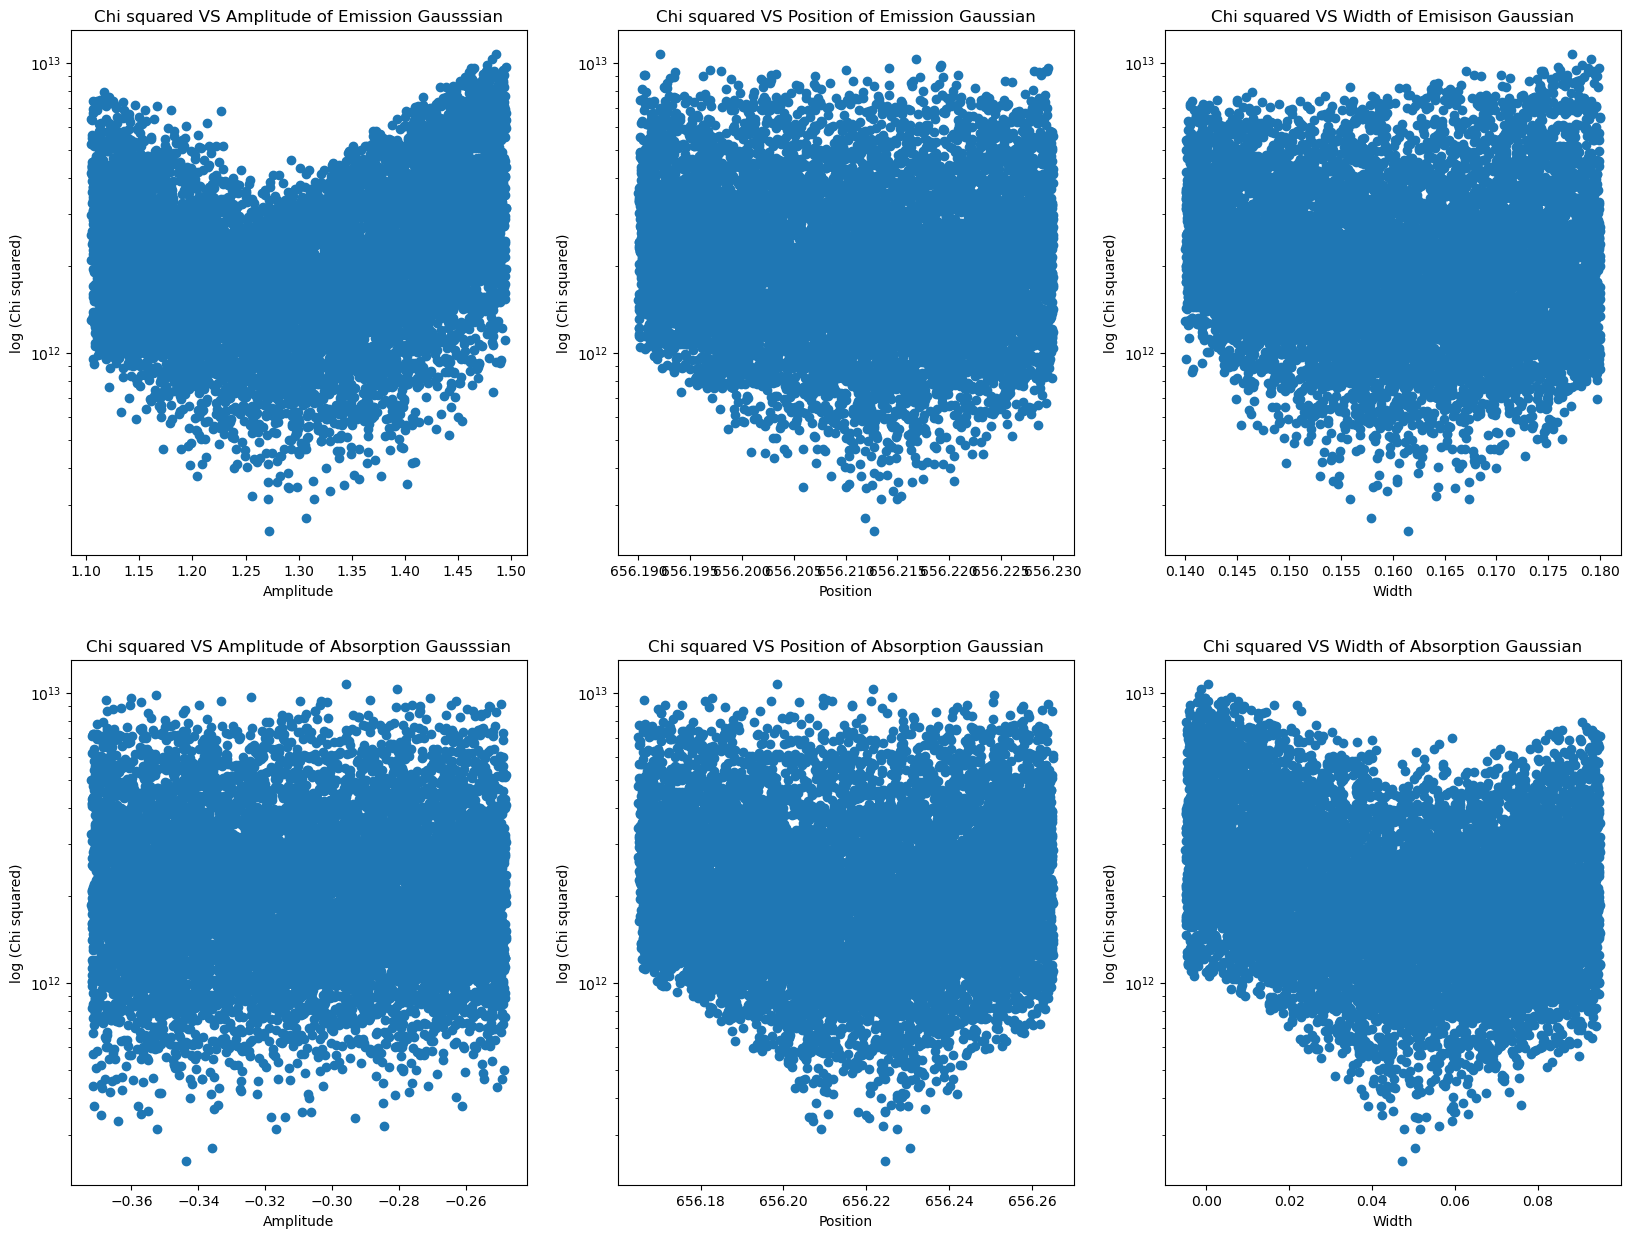

In [253]:
#parameters VS chi sq subplots
fig, ax = plt.subplots(2,3, figsize=(20,15))
ax[0,0].scatter(amplitude_a_emission_mc, chi2_alpha_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('Chi squared VS Amplitude of Emission Gausssian')
ax[0,0].set_xlabel ('Amplitude')
ax[0,0].set_ylabel ('log (Chi squared)')

ax[0,1].scatter(position_a_emission_mc, chi2_alpha_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('Chi squared VS Position of Emission Gaussian')
ax[0,1].set_xlabel ('Position')
ax[0,1].set_ylabel ('log (Chi squared)')

ax[0,2].scatter(width_a_emission_mc , chi2_alpha_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('Chi squared VS Width of Emisison Gaussian')
ax[0,2].set_xlabel ('Width')
ax[0,2].set_ylabel ('log (Chi squared)')

ax[1,0].scatter(amplitude_a_abs_mc, chi2_alpha_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('Chi squared VS Amplitude of Absorption Gausssian')
ax[1,0].set_xlabel ('Amplitude')
ax[1,0].set_ylabel ('log (Chi squared)')

ax[1,1].scatter(position_a_abs_mc, chi2_alpha_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('Chi squared VS Position of Absorption Gaussian')
ax[1,1].set_xlabel ('Position')
ax[1,1].set_ylabel ('log (Chi squared)')

ax[1,2].scatter(width_a_abs_mc, chi2_alpha_mc)
ax[1,2].set_yscale('log')
ax[1,2].set_title ('Chi squared VS Width of Absorption Gaussian')
ax[1,2].set_xlabel ('Width')
ax[1,2].set_ylabel ('log (Chi squared)')
plt.savefig("H_alpha MC, fine tune , n=10000")

Finding the minimum to infer values of fit parameters:

In [256]:
#finding minimum LSR and its index
LSR_alpha_min_index = np.argmin(LSR_alpha_mc)

#finding min of chi squared 
chi2_alpha_min_index = np.argmin(chi2_alpha_mc)

#finding corresponding values through indexing 
min_amp_a_em = amplitude_a_emission_mc[chi2_alpha_min_index]
min_position_a_em = position_a_emission_mc[chi2_alpha_min_index]
min_width_a_em = width_a_emission_mc[chi2_alpha_min_index]
min_amp_a_abs = amplitude_a_abs_mc[chi2_alpha_min_index]
min_position_a_abs = position_a_abs_mc[chi2_alpha_min_index]
min_width_a_abs = width_a_abs_mc[chi2_alpha_min_index]


**Finding errors on MC simulated parameters:**
There was an attempt to find the error on the simulated parameters by taking a one standard deviation confidence interval to estimate the spread of each region of fitted parameter, nevertheless it did not yield feasible results. Hence we chose to estimate the errors, so we choose to estimate the errors through taking the standard deviation of each data set.

In [259]:
#errors as standard deviation 
min_amp_a_em_err = np.std (amplitude_a_emission_mc)
min_position_a_em_err = np.std(position_a_emission_mc)
min_width_a_em_err = np.std (width_a_emission_mc)
min_amp_a_abs_err = np.std(amplitude_a_abs_mc)
min_position_a_abs_err = np.std(position_a_abs_mc)
min_width_a_abs_err = np.std(width_a_abs_mc)



In [261]:
#saving paramters in a list
mc_h_alpha_parameters = [min_amp_a_em, min_position_a_em,min_width_a_em, min_amp_a_abs, min_position_a_abs, min_width_a_abs]
mc_h_alpha_parameters_rounded = np.round(mc_h_alpha_parameters, 3)

mc_h_alpha_parameters_err = [min_amp_a_em_err, min_position_a_em_err, min_width_a_em_err, min_amp_a_abs_err, min_position_a_abs_err, min_width_a_abs_err]
mc_h_alpha_parameters_err_rounded = np.round(mc_h_alpha_parameters_err, 3)


#make output as pandas dataframe
df_results_alpha = pd.DataFrame ({"Monte Carlo simualtion" : mc_h_alpha_parameters_rounded,
                                  "MC error": mc_h_alpha_parameters_err_rounded,
                            "Parameter Estimates": [1.3, 656.21, 0.16, -0.31, 656.215, 0.045]}, 
                           index = ['Amplitude 1 [A.U.]', 'Position 1 [nm]', 'Width 1 [nm]', 'Amplitude 2 [A.U.]', 'Position 2 [nm]', 'Width 2 [nm]'])
df_results_alpha

,Monte Carlo simualtion,MC error,Parameter Estimates
Amplitude 1 [A.U.],1.272,0.112,1.300
Position 1 [nm],656.213,0.012,656.210
Width 1 [nm],0.161,0.012,0.160
Amplitude 2 [A.U.],-0.344,0.036,-0.310
Position 2 [nm],656.224,0.029,656.215
Width 2 [nm],0.047,0.029,0.045


The position of each of the Gaussian fits is going to correspond to its wavelength. Hence for the $H_\alpha$ line we get:

In [264]:
#wavlengths of gaussians
print (f"The wavelength of the H alpha emission feature is: {min_position_a_em:.3f} ± {min_position_a_em_err:.3f} nm")
print (f"The wavelength of the H alpha absorption feature is: {min_position_a_abs:.3f} ± {min_position_a_abs_err:.3f} nm")

The wavelength of the H alpha emission feature is: 656.213 ± 0.012 nm
The wavelength of the H alpha absorption feature is: 656.224 ± 0.029 nm


Let's create a plot with our MC simulated parameters:

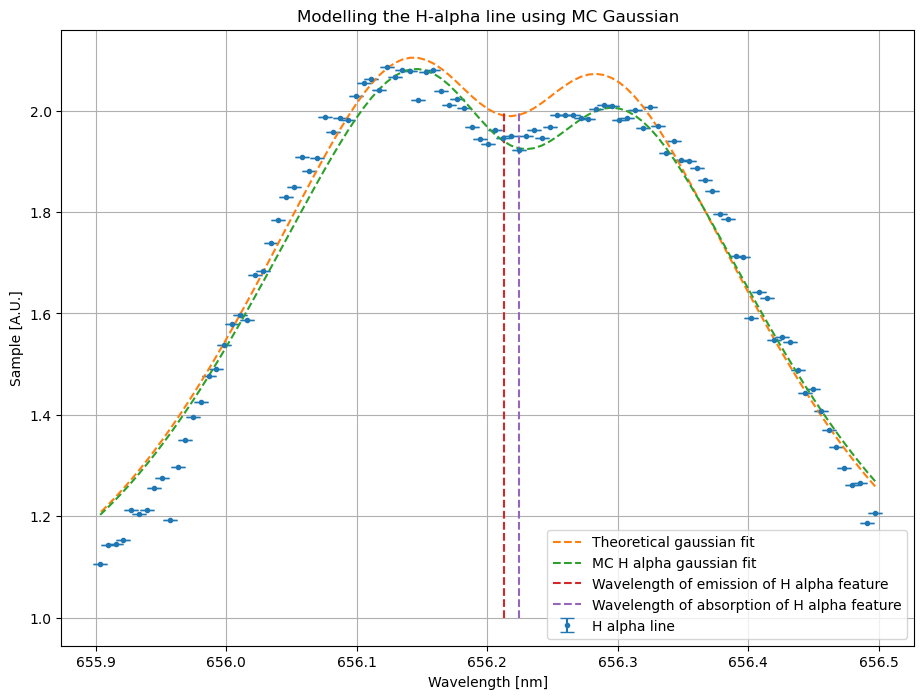

In [267]:
#plotting a curve fit based on our MC outputs
gauss_em_mc = gaussian (alpha_line_wavelength, min_amp_a_em, min_position_a_em,min_width_a_em)
gauss_abs_mc = gaussian (alpha_line_wavelength, min_amp_a_abs, min_position_a_abs, min_width_a_abs)
mc_alpha_line_fit = gauss_em_mc + gauss_abs_mc + 1

#plot
plt.figure(figsize=(11,8))
plt.errorbar(alpha_line_wavelength, alpha_line_y_normalised, yerr=err_y_norm_alpha[alpha_line_id] , capsize= 5, fmt='.', label = 'H alpha line')
plt.plot (alpha_line_wavelength,fit_gauss, "--", label = "Theoretical gaussian fit")
plt.plot (alpha_line_wavelength,mc_alpha_line_fit, "--", label = "MC H alpha gaussian fit") #adding curves
plt.plot((min_position_a_em, min_position_a_em), (1,2), "--" , label = 'Wavelength of emission of H alpha feature')
plt.plot((min_position_a_abs, min_position_a_abs), (1,2), "--" , label = 'Wavelength of absorption of H alpha feature')

plt.title('Modelling the H-alpha line using MC Gaussian')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid()
plt.legend()

From the wavelengths, we can now find the doppler velocity of both of the fitted curves in the MC. We adopt the same procedure as we did in task C, where the velocity is: 
$$
v_{line} = \frac{c \Delta \lambda_{line}}{\lambda_0} 
$$

Where:
- c = speed of light
- $\Delta \lambda_{line}$ = difference in rest and the computed vertex wavelength 
- $\lambda_0$ = rest wavelength of H-alpha (= 656.28 nm [6])

The error for $\Delta v_{line}$ is propagated and added in quadrature to give:
$$
\Delta v_{line} = \frac{c}{\lambda_{0}} * \Delta \lambda_{line}
$$


In [270]:
#speed of emission line
velocity_alpha_emission = ((c * (h_alpha_rest - min_position_a_em)) / (h_alpha_rest) /1000) + v_corr_kms.value
error_velocity_Alcyone_alpha = (((c/h_alpha_rest) * min_position_a_em_err) /1000)
print (f"The radial speed of Alcyone from the H alpha emission feature line is: {velocity_alpha_emission:.3f} ± {error_velocity_Alcyone_alpha:.3f} km/s")

#speed of absorption line 
velocity_alpha_absorption = ((c * (h_alpha_rest - min_position_a_abs)) / (h_alpha_rest) /1000) + v_corr_kms.value
error_velocity_Alcyone_alpha_abs = (((c/h_alpha_rest) * min_position_a_abs_err) /1000)
print (f"The radial speed of Alcyone from the H alpha absorption feature line is: {velocity_alpha_absorption:.3f} ± {error_velocity_Alcyone_alpha_abs:.3f} km/s")


The radial speed of Alcyone from the H alpha emission feature line is: 3.505 ± 5.296 km/s
The radial speed of Alcyone from the H alpha absorption feature line is: -1.822 ± 13.232 km/s


We will comment on these values in the conclusion.

### D.4: Fitting the $H_\beta$ line

We will now proceed to fit the $H_\beta$ line through a Monte Carlo simulation. The process will be analogous to what we did above for the $H_\alpha$ line. Using our previously defined function "Gauss" we will now decided what features we are going to attempt to fit. It is rather obvious that fitting the $H_\beta$ line will be much more challenging than the $H_\alpha$ line. It seems that our best bet is to fit a Gaussian with a negative amplitude and then fit a series of positive Gaussian to detail the features of the line. Let us attempt to visualise that below:

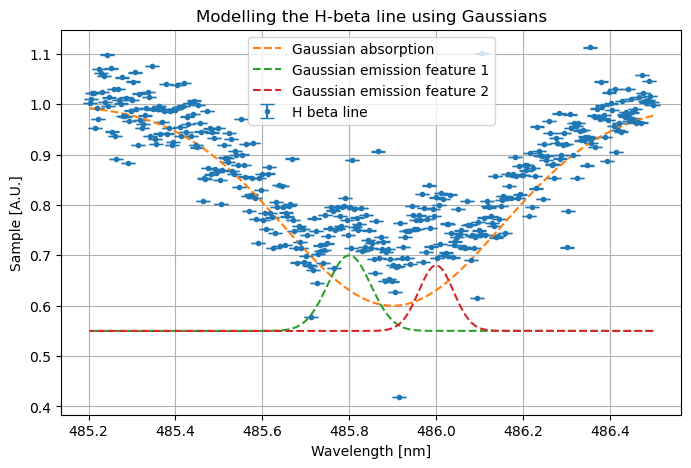

In [274]:
#calling our gaussian function to fit features of the h beta line
gauss_beta_abs = gaussian (beta_line_wavelength, -0.4, 485.9, 0.25) + 1
gauss_beta_peak_1 = gaussian (beta_line_wavelength, 0.15, 485.8, 0.05) + 0.55
gauss_beta_peak_2 = gaussian (beta_line_wavelength, 0.13, 486, 0.04) + 0.55


#plot
plt.figure(figsize=(8,5))

plt.errorbar(beta_line_wavelength, beta_line_y_normalised, yerr=err_y_norm_beta[beta_line_id] , capsize= 5, fmt='.', label = 'H beta line')
plt.plot (beta_line_wavelength,gauss_beta_abs, "--", label = "Gaussian absorption")
plt.plot (beta_line_wavelength,gauss_beta_peak_1, "--", label = "Gaussian emission feature 1")
plt.plot (beta_line_wavelength,gauss_beta_peak_2, "--", label = "Gaussian emission feature 2")

plt.title('Modelling the H-beta line using Gaussians')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid()
plt.legend()


Upon adding these Gaussians we get:

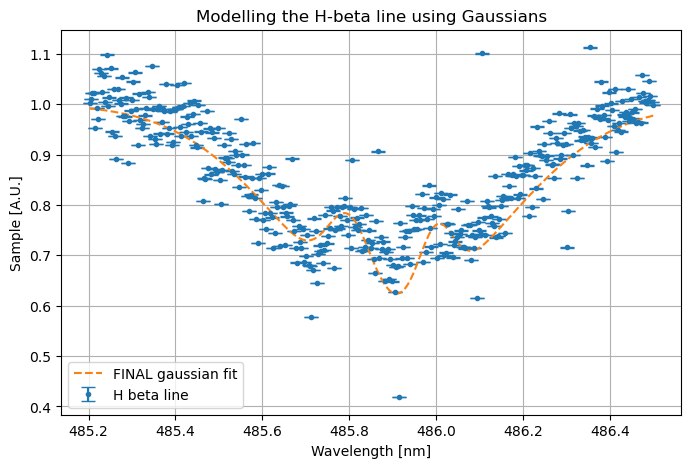

In [277]:
#final line fit for H beta
fit_gauss_beta = gauss_beta_abs + gauss_beta_peak_1 + gauss_beta_peak_2 - 1.1

#plot
plt.figure(figsize=(8,5))
plt.errorbar(beta_line_wavelength, beta_line_y_normalised, yerr=err_y_norm_beta[beta_line_id] , capsize= 5, fmt='.', label = 'H beta line')
plt.plot (beta_line_wavelength,fit_gauss_beta, "--", label = "FINAL gaussian fit")
plt.title('Modelling the H-beta line using Gaussians')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid()
plt.legend()

Hence for our $H_{beta}$ line we will be modelling three Gaussian which once added will yield our fit encapsulating both the absorption feature and the two most distinct dips. We store our "guessed" values that we obatined through this fitting:

In [280]:
#saving our estimates from the beta fits above
amplitude_beta_abs = -0.4
position_beta_abs = 485.9
width_beta_abs = 0.25

amplitude_beta_peak1= 0.15
position_beta_peak1 = 485.8
width_beta_peak1 = 0.05

amplitude_beta_peak2= 0.13
position_beta_peak2 = 486
width_beta_peak2 = 0.04

We can now set up our MC fitting for the 9 parameters of the $H_\beta$ line:

In [283]:
# monte carlo simulations set up from week 5'
n = 1000

#define empty arrays
amplitude_b_abs_mc =np.array([])
position_b_abs_mc = np.array([])
width_b_abs_mc = np.array([])

amplitude_b_peak1_mc =np.array([])
position_b_peak1_mc = np.array([])
width_b_peak1_mc = np.array([])

amplitude_b_peak2_mc =np.array([])
position_b_peak2_mc = np.array([])
width_b_peak2_mc = np.array([])

LSR_beta_mc = np.array ([])
chi2_beta_mc = np.array ([])

#loop
for x in range (n):
    amplitude_b_abs_run = random.uniform(amplitude_beta_abs * 0.8, amplitude_beta_abs * 1.2)
    position_b_abs_run = random.uniform(position_beta_abs - 0.05, position_beta_abs + 0.05)
    width_b_abs_run = random.uniform(width_beta_abs - 0.05, width_beta_abs + 0.05)

    amplitude_b_peak1_run = random.uniform(amplitude_beta_peak1 * 0.8, amplitude_beta_peak1 * 1.2)
    position_b_peak1_run = random.uniform(position_beta_peak1 - 0.05, position_beta_peak1 + 0.05)
    width_b_peak1_run = random.uniform(width_beta_peak1 - 0.05, width_beta_peak1 + 0.05)

    amplitude_b_peak2_run = random.uniform(amplitude_beta_peak2 * 0.8, amplitude_beta_peak2 * 1.2)
    position_b_peak2_run = random.uniform(position_beta_peak2 - 0.05, position_beta_peak2 + 0.05)
    width_b_peak2_run = random.uniform(width_beta_peak2 - 0.05, width_beta_peak2 + 0.05)

    #gaussian
    mc_gauss_b = gaussian(beta_line_wavelength, amplitude_b_abs_run, position_b_abs_run, width_b_abs_run)
    mc_gauss_b_1 = gaussian(beta_line_wavelength, amplitude_b_peak1_run, position_b_peak1_run, width_b_peak1_run)
    mc_gauss_b_2 = gaussian(beta_line_wavelength, amplitude_b_peak2_run, position_b_peak2_run, width_b_peak2_run)
    
    #final fit 
    fit_beta_mc = mc_gauss_b + mc_gauss_b_1 + mc_gauss_b_2 + 1
    
    #lSR & chi2
    LSR_beta_run =np.sum((beta_line_y_normalised - fit_beta_mc)**2)
    chi2_beta_run = np.sum (((beta_line_y_normalised - fit_beta_mc)**2) / (err_y_norm_beta[beta_line_id])**2)
    
    #append    
    amplitude_b_abs_mc = np.append(amplitude_b_abs_mc, amplitude_b_abs_run)
    position_b_abs_mc = np.append(position_b_abs_mc, position_b_abs_run)
    width_b_abs_mc = np.append(width_b_abs_mc, width_b_abs_run)

    amplitude_b_peak1_mc = np.append(amplitude_b_peak1_mc, amplitude_b_peak1_run)
    position_b_peak1_mc = np.append(position_b_peak1_mc, position_b_peak1_run)
    width_b_peak1_mc = np.append(width_b_peak1_mc, width_b_peak1_run)

    amplitude_b_peak2_mc = np.append(amplitude_b_peak2_mc, amplitude_b_peak2_run)
    position_b_peak2_mc = np.append(position_b_peak2_mc, position_b_peak2_run)
    width_b_peak2_mc = np.append(width_b_peak2_mc, width_b_peak2_run)
    

    LSR_beta_mc = np.append (LSR_beta_mc, LSR_beta_run)
    chi2_beta_mc = np.append(chi2_beta_mc, chi2_beta_run)

    

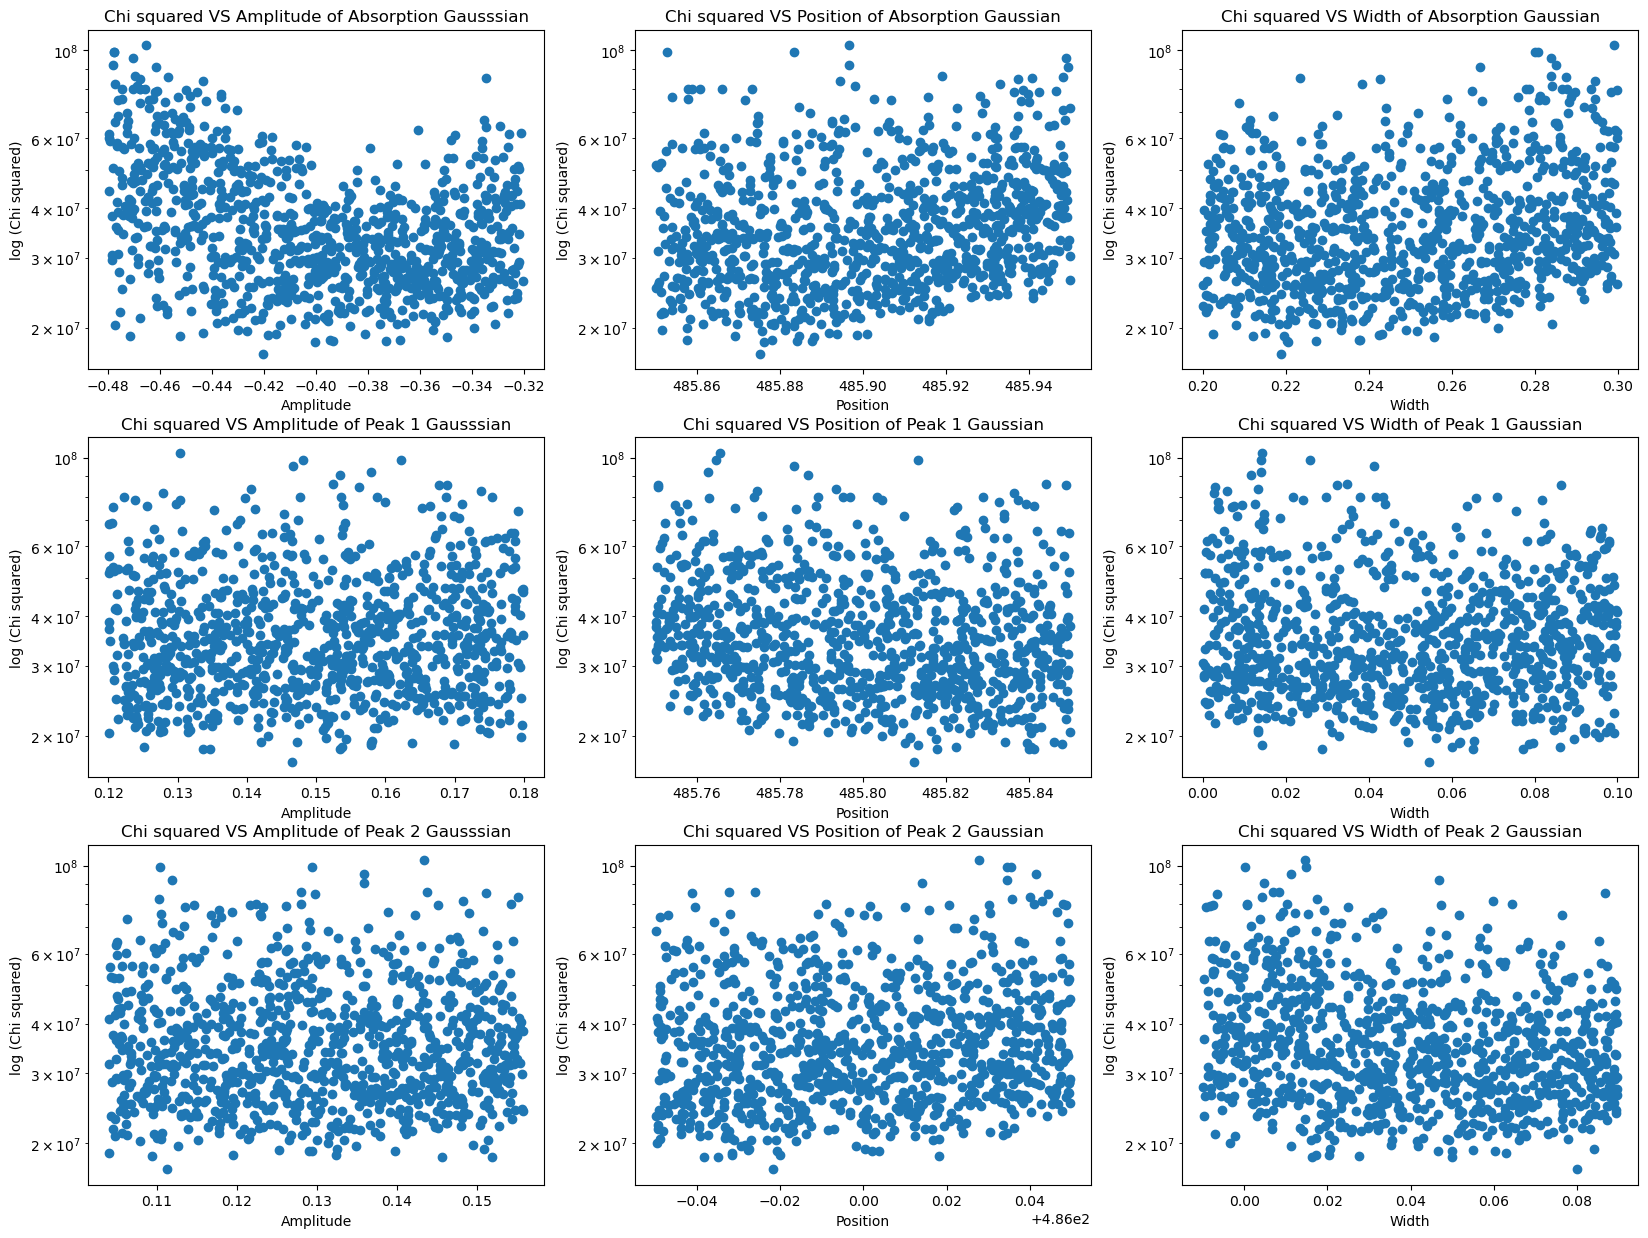

In [285]:
#parameters VS chi sq subplots
fig, ax = plt.subplots(3,3, figsize=(20,15))

ax[0,0].scatter(amplitude_b_abs_mc, chi2_beta_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('Chi squared VS Amplitude of Absorption Gausssian')
ax[0,0].set_xlabel ('Amplitude')
ax[0,0].set_ylabel ('log (Chi squared)')

ax[0,1].scatter(position_b_abs_mc, chi2_beta_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('Chi squared VS Position of Absorption Gaussian')
ax[0,1].set_xlabel ('Position')
ax[0,1].set_ylabel ('log (Chi squared)')

ax[0,2].scatter(width_b_abs_mc, chi2_beta_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('Chi squared VS Width of Absorption Gaussian')
ax[0,2].set_xlabel ('Width')
ax[0,2].set_ylabel ('log (Chi squared)')

ax[1,0].scatter(amplitude_b_peak1_mc, chi2_beta_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('Chi squared VS Amplitude of Peak 1 Gausssian')
ax[1,0].set_xlabel ('Amplitude')
ax[1,0].set_ylabel ('log (Chi squared)')

ax[1,1].scatter(position_b_peak1_mc, chi2_beta_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('Chi squared VS Position of Peak 1 Gaussian')
ax[1,1].set_xlabel ('Position')
ax[1,1].set_ylabel ('log (Chi squared)')

ax[1,2].scatter(width_b_peak1_mc, chi2_beta_mc)
ax[1,2].set_yscale('log')
ax[1,2].set_title ('Chi squared VS Width of Peak 1 Gaussian')
ax[1,2].set_xlabel ('Width')
ax[1,2].set_ylabel ('log (Chi squared)')

ax[2,0].scatter(amplitude_b_peak2_mc, chi2_beta_mc)
ax[2,0].set_yscale('log')
ax[2,0].set_title ('Chi squared VS Amplitude of Peak 2 Gausssian')
ax[2,0].set_xlabel ('Amplitude')
ax[2,0].set_ylabel ('log (Chi squared)')

ax[2,1].scatter(position_b_peak2_mc, chi2_beta_mc)
ax[2,1].set_yscale('log')
ax[2,1].set_title ('Chi squared VS Position of Peak 2 Gaussian')
ax[2,1].set_xlabel ('Position')
ax[2,1].set_ylabel ('log (Chi squared)')

ax[2,2].scatter(width_b_peak2_mc, chi2_beta_mc)
ax[2,2].set_yscale('log')
ax[2,2].set_title ('Chi squared VS Width of Peak 2 Gaussian')
ax[2,2].set_xlabel ('Width')
ax[2,2].set_ylabel ('log (Chi squared)')

#save image
plt.savefig("H_beta MC, chi sq, n=1000")

Hence for our initial Monte Carlo set up for n = 1000, we obtain:
![H_beta MC n=1000](<H_beta MC, chi sq, n=1000.png>)

Increasing the number of iterations to n = 10000, we obtain:
![H_beta MC n=10000](<H_beta MC, chi sq, n=10000.png>)

Let us now fine-tune our plots slightly, nevertheless from initial inspection it appears that the $\chi ^2$ is not biased towards any of our parameters. 

In [290]:
n = 10000

#define empty arrays
amplitude_b_abs_mc =np.array([])
position_b_abs_mc = np.array([])
width_b_abs_mc = np.array([])

amplitude_b_peak1_mc =np.array([])
position_b_peak1_mc = np.array([])
width_b_peak1_mc = np.array([])

amplitude_b_peak2_mc =np.array([])
position_b_peak2_mc = np.array([])
width_b_peak2_mc = np.array([])

LSR_beta_mc = np.array ([])
chi2_beta_mc = np.array ([])

#loop
for x in range (n):
    amplitude_b_abs_run = random.uniform(amplitude_beta_abs * 0.99, amplitude_beta_abs * 1.01)
    position_b_abs_run = random.uniform(position_beta_abs - 0.005, position_beta_abs + 0.005)
    width_b_abs_run = random.uniform(width_beta_abs - 0.005, width_beta_abs + 0.005)

    amplitude_b_peak1_run = random.uniform(amplitude_beta_peak1 * 0.95, amplitude_beta_peak1 * 1.05)
    position_b_peak1_run = random.uniform(position_beta_peak1 - 0.005, position_beta_peak1 + 0.005)
    width_b_peak1_run = random.uniform(width_beta_peak1 - 0.01, width_beta_peak1 + 0.01)

    amplitude_b_peak2_run = random.uniform(amplitude_beta_peak2 * 0.95, amplitude_beta_peak2 * 1.05)
    position_b_peak2_run = random.uniform(position_beta_peak2 - 0.005, position_beta_peak2 + 0.005)
    width_b_peak2_run = random.uniform(width_beta_peak2 - 0.005, width_beta_peak2 + 0.005)
    
    #gaussian
    mc_gauss_b = gaussian(beta_line_wavelength, amplitude_b_abs_run, position_b_abs_run, width_b_abs_run)
    mc_gauss_b_1 = gaussian(beta_line_wavelength, amplitude_b_peak1_run, position_b_peak1_run, width_b_peak1_run)
    mc_gauss_b_2 = gaussian(beta_line_wavelength, amplitude_b_peak2_run, position_b_peak2_run, width_b_peak2_run)
    
    #final fit 
    fit_beta_mc = mc_gauss_b + mc_gauss_b_1 + mc_gauss_b_2 + 1
    
    #lSR & chi2
    LSR_beta_run =np.sum((beta_line_y_normalised - fit_beta_mc)**2)
    chi2_beta_run = np.sum (((beta_line_y_normalised - fit_beta_mc)**2) / (err_y_norm_beta[beta_line_id])**2)
    
    #append    
    amplitude_b_abs_mc = np.append(amplitude_b_abs_mc, amplitude_b_abs_run)
    position_b_abs_mc = np.append(position_b_abs_mc, position_b_abs_run)
    width_b_abs_mc = np.append(width_b_abs_mc, width_b_abs_run)

    amplitude_b_peak1_mc = np.append(amplitude_b_peak1_mc, amplitude_b_peak1_run)
    position_b_peak1_mc = np.append(position_b_peak1_mc, position_b_peak1_run)
    width_b_peak1_mc = np.append(width_b_peak1_mc, width_b_peak1_run)

    amplitude_b_peak2_mc = np.append(amplitude_b_peak2_mc, amplitude_b_peak2_run)
    position_b_peak2_mc = np.append(position_b_peak2_mc, position_b_peak2_run)
    width_b_peak2_mc = np.append(width_b_peak2_mc, width_b_peak2_run)
    

    LSR_beta_mc = np.append (LSR_beta_mc, LSR_beta_run)
    chi2_beta_mc = np.append(chi2_beta_mc, chi2_beta_run)


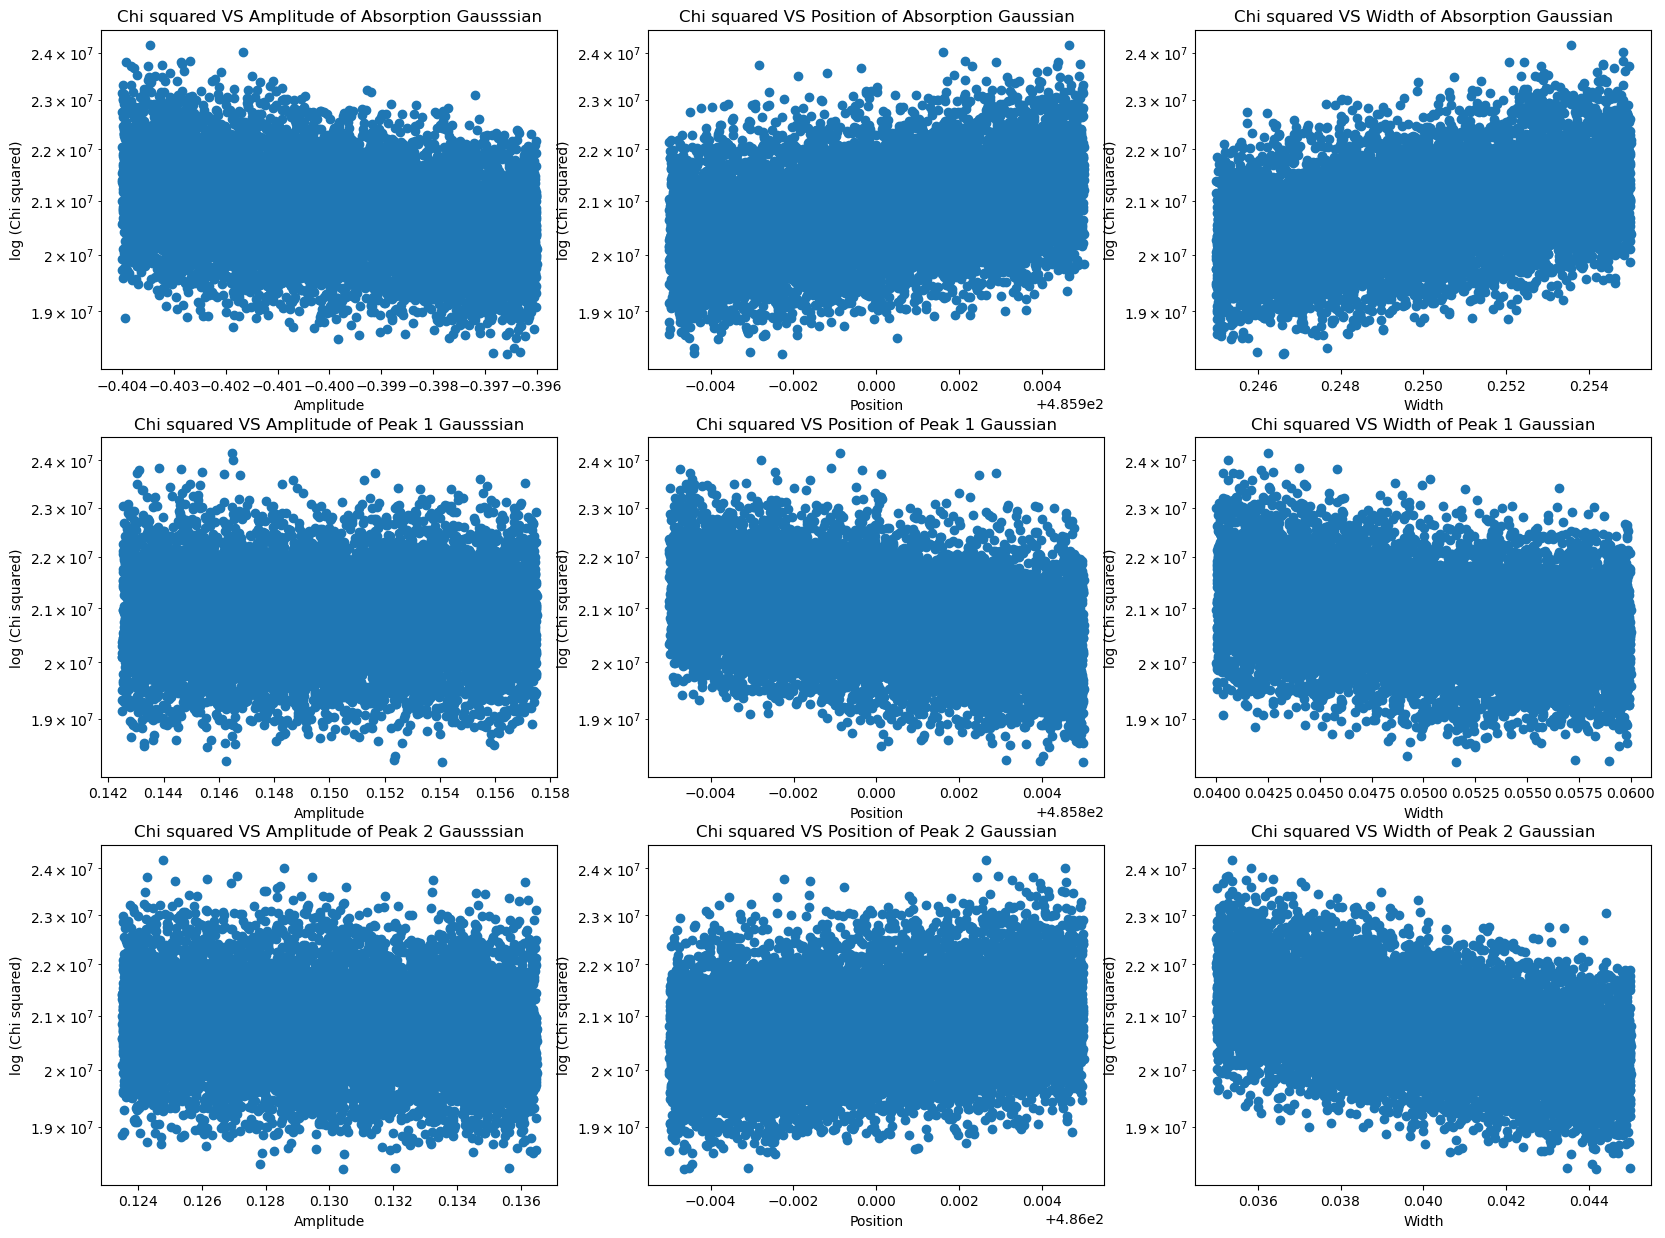

In [292]:
#parameters VS chi sq subplots
fig, ax = plt.subplots(3,3, figsize=(20,15))

ax[0,0].scatter(amplitude_b_abs_mc, chi2_beta_mc)
ax[0,0].set_yscale('log')
ax[0,0].set_title ('Chi squared VS Amplitude of Absorption Gausssian')
ax[0,0].set_xlabel ('Amplitude')
ax[0,0].set_ylabel ('log (Chi squared)')

ax[0,1].scatter(position_b_abs_mc, chi2_beta_mc)
ax[0,1].set_yscale('log')
ax[0,1].set_title ('Chi squared VS Position of Absorption Gaussian')
ax[0,1].set_xlabel ('Position')
ax[0,1].set_ylabel ('log (Chi squared)')

ax[0,2].scatter(width_b_abs_mc, chi2_beta_mc)
ax[0,2].set_yscale('log')
ax[0,2].set_title ('Chi squared VS Width of Absorption Gaussian')
ax[0,2].set_xlabel ('Width')
ax[0,2].set_ylabel ('log (Chi squared)')

ax[1,0].scatter(amplitude_b_peak1_mc, chi2_beta_mc)
ax[1,0].set_yscale('log')
ax[1,0].set_title ('Chi squared VS Amplitude of Peak 1 Gausssian')
ax[1,0].set_xlabel ('Amplitude')
ax[1,0].set_ylabel ('log (Chi squared)')

ax[1,1].scatter(position_b_peak1_mc, chi2_beta_mc)
ax[1,1].set_yscale('log')
ax[1,1].set_title ('Chi squared VS Position of Peak 1 Gaussian')
ax[1,1].set_xlabel ('Position')
ax[1,1].set_ylabel ('log (Chi squared)')

ax[1,2].scatter(width_b_peak1_mc, chi2_beta_mc)
ax[1,2].set_yscale('log')
ax[1,2].set_title ('Chi squared VS Width of Peak 1 Gaussian')
ax[1,2].set_xlabel ('Width')
ax[1,2].set_ylabel ('log (Chi squared)')

ax[2,0].scatter(amplitude_b_peak2_mc, chi2_beta_mc)
ax[2,0].set_yscale('log')
ax[2,0].set_title ('Chi squared VS Amplitude of Peak 2 Gausssian')
ax[2,0].set_xlabel ('Amplitude')
ax[2,0].set_ylabel ('log (Chi squared)')

ax[2,1].scatter(position_b_peak2_mc, chi2_beta_mc)
ax[2,1].set_yscale('log')
ax[2,1].set_title ('Chi squared VS Position of Peak 2 Gaussian')
ax[2,1].set_xlabel ('Position')
ax[2,1].set_ylabel ('log (Chi squared)')

ax[2,2].scatter(width_b_peak2_mc, chi2_beta_mc)
ax[2,2].set_yscale('log')
ax[2,2].set_title ('Chi squared VS Width of Peak 2 Gaussian')
ax[2,2].set_xlabel ('Width')
ax[2,2].set_ylabel ('log (Chi squared)')

#save image
plt.savefig("H_beta MC fine tune, n=10000")

We can now find the minima of our fine-tuned parameters:

In [295]:
#finding minimum LSR and its index
LSR_beta_min_index = np.argmin(LSR_beta_mc)

#finding min of chi squared 
chi2_beta_min_index = np.argmin(chi2_beta_mc)

#finding corresponding values through indexing 
min_amp_b_abs = amplitude_b_abs_mc[chi2_beta_min_index]
min_position_b_abs = position_b_abs_mc[chi2_beta_min_index]
min_width_b_abs = width_b_abs_mc[chi2_beta_min_index]

min_amp_b_peak1 = amplitude_b_peak1_mc[chi2_alpha_min_index]
min_position_b_peak1 = position_b_peak1_mc[chi2_alpha_min_index]
min_width_b_peak1 = width_b_peak1_mc[chi2_alpha_min_index]

min_amp_b_peak2 = amplitude_b_peak2_mc[chi2_alpha_min_index]
min_position_b_peak2 = position_b_peak2_mc[chi2_alpha_min_index]
min_width_b_peak2 = width_b_peak2_mc[chi2_alpha_min_index]


As for $H_\alpha$ we estimate the errors using a standard deviation of the data set:

In [298]:
#errors as standard deviation 
min_amp_b_abs_err = np.std (amplitude_b_abs_mc)
min_position_b_abs_err = np.std(position_b_abs_mc)
min_width_b_abs_err = np.std (width_b_abs_mc)


min_amp_b_peak1_err = np.std(amplitude_b_peak1_mc)
min_position_b_peak1_err = np.std(position_b_peak1_mc)
min_width_b_peak1_err = np.std(width_b_peak1_mc)

min_amp_b_peak2_err = np.std(amplitude_b_peak2_mc)
min_position_b_peak2_err = np.std(position_b_peak2_mc)
min_width_b_peak2_err = np.std(width_b_peak2_mc)

In [300]:
#saving paramters in a list
mc_h_beta_parameters = [min_amp_b_abs, min_position_b_abs, min_width_b_abs, min_amp_b_peak1, min_position_b_peak1 , min_width_b_peak1, min_amp_b_peak2, min_position_b_peak2, min_width_b_peak2 ]
mc_h_beta_parameters_rounded = np.round(mc_h_beta_parameters, 3)

mc_h_beta_err = [min_amp_b_abs_err, min_position_b_abs_err, min_width_b_abs_err, min_amp_b_peak1_err, min_position_b_peak1_err , min_width_b_peak1_err, min_amp_b_peak2_err, min_position_b_peak2_err, min_width_b_peak2_err]
mc_h_beta_err_rounded = np.round(mc_h_beta_err, 3)

h_beta_parameters_estimates = [amplitude_beta_abs, position_beta_abs, width_beta_abs, amplitude_beta_peak1, position_beta_peak1, width_beta_peak1, amplitude_beta_peak2, position_beta_peak2, width_beta_peak2  ]

#make output as pandas dataframe
df_results_beta = pd.DataFrame ({"Monte Carlo simualtion" : mc_h_beta_parameters_rounded, 
                                 "MC error": mc_h_beta_err_rounded,
                            "Parameter Estimates": h_beta_parameters_estimates}, 
                           index = ['Amplitude 1 [A.U.]', 'Position 1 [nm]', 'Width 1 [nm]', 'Amplitude 2 [A.U.]', 'Position 2 [nm]', 'Width 2 [nm]', 'Amplitude 3 [A.U.]', 'Position 3 [nm]', 'Width 3 [nm]'])
df_results_beta

,Monte Carlo simualtion,MC error,Parameter Estimates
Amplitude 1 [A.U.],-0.397,0.002,-0.40
Position 1 [nm],485.898,0.003,485.90
Width 1 [nm],0.247,0.003,0.25
Amplitude 2 [A.U.],0.151,0.004,0.15
Position 2 [nm],485.805,0.003,485.80
Width 2 [nm],0.045,0.006,0.05
Amplitude 3 [A.U.],0.129,0.004,0.13
Position 3 [nm],486.003,0.003,486.00
Width 3 [nm],0.045,0.003,0.04


The position of each of the Gaussian fits is going to correspond to its wavelength. Hence for the $H_\beta$ line we get:

In [303]:
#wavlengths of gaussians
print (f"The wavelength of the H alpha absorption feature is: {min_position_b_abs:.3f} ± {min_position_b_abs_err:.3f} nm")
print (f"The wavelength of the H alpha peak 1 feature is: {min_position_b_peak1:.3f} ± {min_position_b_peak1_err:.3f} nm")
print (f"The wavelength of the H alpha peak 2 feature is: {min_position_b_peak2:.3f} ± {min_position_b_peak2_err:.3f} nm")

The wavelength of the H alpha absorption feature is: 485.898 ± 0.003 nm
The wavelength of the H alpha peak 1 feature is: 485.805 ± 0.003 nm
The wavelength of the H alpha peak 2 feature is: 486.003 ± 0.003 nm


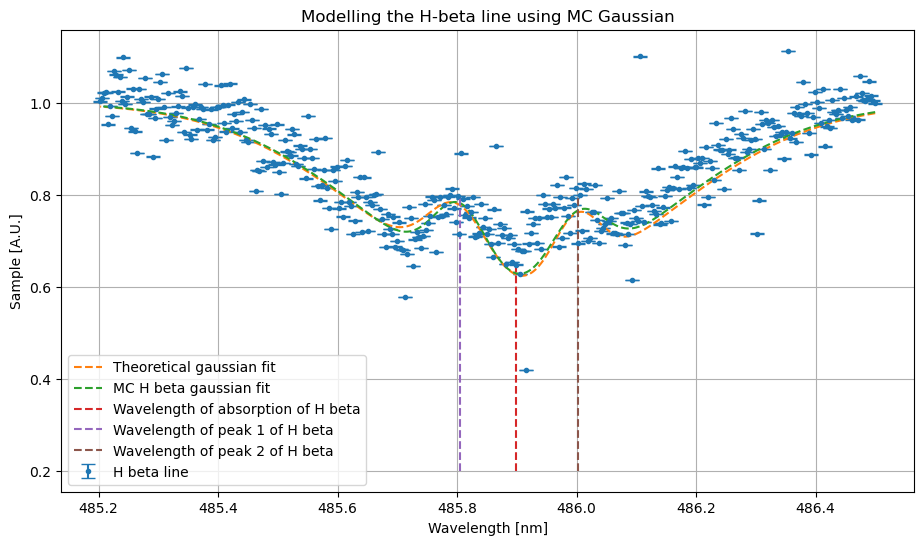

In [305]:
#plotting a curve fit based on our MC outputs
gauss_beta_abs_mc = gaussian (beta_line_wavelength, min_amp_b_abs, min_position_b_abs, min_width_b_abs)
gauss_beta_peak1_mc = gaussian (beta_line_wavelength, min_amp_b_peak1, min_position_b_peak1 , min_width_b_peak1)
gauss_beta_peak2_mc = gaussian (beta_line_wavelength, min_amp_b_peak2, min_position_b_peak2, min_width_b_peak2)

mc_beta_line_fit = gauss_beta_abs_mc + gauss_beta_peak1_mc + gauss_beta_peak2_mc + 1

#plot
plt.figure(figsize=(11,6))
plt.errorbar(beta_line_wavelength, beta_line_y_normalised, yerr=err_y_norm_beta[beta_line_id] , capsize= 5, fmt='.', label = 'H beta line')
plt.plot (beta_line_wavelength,fit_gauss_beta, "--", label = "Theoretical gaussian fit")
plt.plot (beta_line_wavelength,mc_beta_line_fit, "--", label = "MC H beta gaussian fit")
plt.plot((min_position_b_abs, min_position_b_abs), (0.2,0.65), "--" , label = 'Wavelength of absorption of H beta')
plt.plot((min_position_b_peak1, min_position_b_peak1), (0.2,0.8), "--" , label = 'Wavelength of peak 1 of H beta')
plt.plot((min_position_b_peak2, min_position_b_peak2), (0.2,0.8), "--" , label = 'Wavelength of peak 2 of H beta')

plt.title('Modelling the H-beta line using MC Gaussian')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Sample [A.U.]')
plt.grid()
plt.legend()

From the wavelengths, we can now find the doppler velocity of both of the fitted curves in the MC. We adopt the same procedure as we did in task C and for $H_\alpha$ in task D:

In [310]:
#speed of absorption line
velocity_beta_abs = ((c * (h_beta_rest - min_position_b_abs)) / (h_alpha_rest) /1000) + v_corr_kms.value
error_velocity_Alcyone_b_abs = (((c/h_beta_rest) * min_position_b_abs_err) /1000)
print (f"The radial speed of Alcyone from the H alpha emission feature line is: {velocity_beta_abs:.3f} ± {error_velocity_Alcyone_b_abs:.3f} km/s")

#speed of peak 1 line 
velocity_beta_peak1 = ((c * (h_beta_rest - min_position_b_peak1)) / (h_alpha_rest) /1000) + v_corr_kms.value
error_velocity_Alcyone_b_peak1 = (((c/h_beta_rest) * min_position_b_peak1_err) /1000)
print (f"The radial speed of Alcyone from the H alpha peak 1 feature is: {velocity_beta_peak1:.3f} ± {error_velocity_Alcyone_b_peak1:.3f} km/s")

#speed of peak 2 line 
velocity_beta_peak2 = ((c * (h_beta_rest - min_position_b_peak2)) / (h_alpha_rest) /1000) + v_corr_kms.value
error_velocity_Alcyone_b_peak2 = (((c/h_beta_rest) * min_position_b_peak2_err) /1000)
print (f"The radial speed of Alcyone from the H alpha peak 2 feature is: {velocity_beta_peak2:.3f} ± {error_velocity_Alcyone_b_peak2:.3f} km/s")


The radial speed of Alcyone from the H alpha emission feature line is: 65.229 ± 1.779 km/s
The radial speed of Alcyone from the H alpha peak 1 feature is: 107.824 ± 1.778 km/s
The radial speed of Alcyone from the H alpha peak 2 feature is: 17.273 ± 1.779 km/s


We will comment on these values in the conclusion.

## TASK E: Conclusions

In this task, we have completed a series of complex fittings of the $H_\alpha$ and $H_\beta$ spectral lines of Alcyone. Through fitting the lines using an np.polyfit, we obtained the following wavelength for each of the lines, respectively: $\lambda_\alpha$ = 656.21110 ± 0.00172 nm and $\lambda_\beta$ = 485.87352 ± 0.00551 nm. We used these values to calculate the radial velocity (with a heliospheric correction) to be $v_{alpha}$ = 4.262 ± 0.788 km/s and $v_{beta}$ = 112.536 ± 3.402 km/s. The published radial velocity of Alcyone is 5.4 km/s $^{[1]}$. This indicates that our $H_\alpha$ line is a more suitable indicator of radial velocity from the np.polyfit().

Nonetheless, the picture gets more complex when we fit each of the spectral line features, as we have seen that these lines are not just clean absorption and emission lines. We use a Monte Carlo simulation to fit 2 Gaussians for the $H_\alpha$ and 3 Gaussians for $H_\beta$ spectral lines. This simulation leaves us three fit parameters (amplitude, mean, standard deviation) for each of the Gaussians fitted. We use the mean to deduce the wavelength of each of the fits. Ultimately, we calculate the radial velocity for each of the fits of each of the lines. Our $H_\alpha$ line is simulated by a large emission peak with a small absorption, yielding the velocities: $v_{emission}$ = 3.505 ± 5.296 km/s and the $v_{absorption}$ = -1.822 ± 13.232 km/s. These align with the np.polyfit() speed we obtain as well as the published radial velocity of Alcyone. From what we know about stellar physics of B-type stars, the $v_{absorption}$ should represent the radial velocity of the star, whereas $v_{emission}$ stems from the circumstellar disc and the nebulous region the star is embedded in. This is what results in the double-peak shape we observe in our $H_\alpha$ line.  Nevetheless our error on the $v_{absorption}$ is rather large for the $H_\alpha$ line, indicating that a more complex error propagation should be adopted when finding the error on our MC simulation parameters to gain a more nuanced understanding of our results. 

For the $H_\beta$ line, we fitted a wide absorption line and two small emission lines to represent the shape of the line. The velocities we get are: $v_{absorption}$ = 65.229 ± 1.779 km/s, $v_{peak1}$ = 107.824 ± 1.778 km/s and $v_{peak2}$ = 17.273 ± 1.779 km/s. This would indicate that the $\lambda_{peak1}$ correpsonds the best to our $\lambda_\beta$ that we got for the np.polyfit(). Furthermore, the variations between the radial velocities are larger than for $\lambda_\alpha$, and they deviate more from the published value of the radial velocity of Alcyone. 

Let us now investigate the reasons why the $H_\alpha$ line seems to be a better indicator of radial velocity than $H_\beta$. Firstly, just from our visualisations of both spectral lines, we see that the $H_\beta$ line possesses a larger number of complex features than $H_\alpha$, which makes the identification of wavelength more taxing. Additionally, as stated by Heasley and Woff, the $H_\alpha$ line is less sensitive to pressure and temperature variations, which makes it a more suitable choice to infer physical parameters than other Balmer lines $^{[12]}$. Additionally, this would make $H_\alpha$ a suitable choice to infer the effective temperature of Alycone. This, however, is beyond the scope of this task. Alternatively, we can hypothesise if the calibration of the spectrometer on the Perren telescope could also explain the difficulty we encounter in inferring the radial velocity from the $H_\beta$ line. That would imply that incorrect spectrograph calibration only targets certain spectral lines. 

We have already hintted to a possible extension of this task in which we could calculate $T_{eff}$ using the Balmer thermometer. If we had access to a wider set of spectra for Alcyone, we could also construct an empirical curve of growth and use it to infer the temperature that way. An extension that is more relevant for the task would be to develop a method that allows us to calculate errors more suitably for our MC-estimated parameters. This could, for instance, include numerical methods (that were initially attempted in the task but were unsuccessful) or using an MCMC simulation that yields errors in estimated parameters. 

## References

[1] G. A. Gontcharov. Pulkovo Compilation of Radial Velocities for 35 495 Hipparcos stars in a common system, Astronomy Letters, Vol. 32, Issue 11, p.759-771, November 2006, https://arxiv.org/abs/1606.08053. 

[2] White et al. Beyond the Kepler/K2 bright limit: variability in the seven brightest members of the Pleiades, Monthly Notices of the Royal Astronomical Society, Volume 471, Issue 3, November 2017, Pages 2882–2901, https://doi.org/10.1093/mnras/stx1050

[3] Spectral Classification of B-type stars. [online] Georgia State University [Accessed 5 of March 2026.] Available from: https://astro.gsu.edu/~gies/ASTR8000/lester.pdf.

[4] Cayrel et al. The Hα Balmer line as an effective temperature criterion, Astronomy & Astrophysics, Volume 531 A83, 16 July 2011, https://www.aanda.org/articles/aa/full_html/2011/07/aa16911-11/aa16911-11.html. 

[5] M. Pettini. Stellar Atmospheres II: The analysis of absorption lines. [online] Structure and Evolution of Stars [Accessed 4 March 2026.] Available from: https://moodle.ucl.ac.uk/pluginfile.php/9810121/mod_folder/content/0/MaxPettini_Lecture06.pdf?forcedownload=1. 

[6] Atomic Data for Hydrogen (H). [online] NIST [Accessed 3 March 2026]. Available from: https://physics.nist.gov/PhysRefData/Handbook/Tables/hydrogentable1.htm. 

[7] Llorente-Garcia I and Jones P. Data Analysis and Statistics Booklet, Practical Physics and Computing 1: Module PHAS0007. [online] UCL: London; 2022 [Accessed 10 November 2024]. Available from: https://moodle.ucl.ac.uk/course/view.php?id=46794&section=1.

[8] Method of Least Squares. [online] Niels Bohr Institutet [Acessessed 3 March 2026]. Available from: https://www.nbi.dk/~petersen/Teaching/Stat2024/Week1/AS2024_11_22_ChiSquare.pdf.

[9] GeoHack - UCL Observatory. [online] GeoHack [Accessed 3 March 2026]. Available from: https://geohack.toolforge.org/geohack.php?pagename=UCL_Observatory&params=51.6134_N_0.242_W_

[10] * eta Tau. [online] Simbad [Accessed 3 March 2026]. Available from: https://simbad.u-strasbg.fr/simbad/sim-id?protocol=html&Ident=25+Tau&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id. 

[11]  Gaussian function. [online] Wikipedia [Accessed 26 February 2026]. Available from: https://en.wikipedia.org/wiki/Gaussian_function.

[12] Heasley and Woff. Ha LINE PROFILES IN B STARS: COMPARISON OF THEORY AND OBSERVATIONS, The astrophysical journal, Vol 269, p. 634 - 640, 15 June 1993. 